# 📊 PHASE zzity report + insights

---

In [1]:
# Set working directory to project root
import os
from pathlib import Path
from IPython.display import display

# Find project root robustly from the current notebook location or cwd
candidate_paths = [Path.cwd()] + list(Path.cwd().parents)
project_root = None
for candidate in candidate_paths:
    if (candidate / 'src' / 'scripts' / 'config.py').exists():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError("Unable to locate project root containing src/scripts/config.py")

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.insert(0, str(project_root / 'src' / 'scripts'))
from config import RAW_DATA_FILE, FORVIA_COLORS
from logger import get_logger

logger = get_logger(__name__)

# Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette(FORVIA_COLORS)

print("✅ Imports successful!")

Working directory set to: C:\Users\1boughai\Desktop\IDP-Monitoring-Project


2026-06-12 16:53:55,525 - logger - INFO - 🔧 DEBUG MODE ENABLED


2026-06-12 16:53:55,529 - logger - INFO - 📝 Logs saved to: C:\Users\1boughai\Desktop\IDP-Monitoring-Project\src\outputs\project_20260612_165355.log


✅ Imports successful!


## 1️⃣ DATA LOADING & BASIC INFO

In [2]:
# Load data
logger.info(f"Loading data from {RAW_DATA_FILE}")
df = pd.read_csv(RAW_DATA_FILE, low_memory=False)

print(f"\n📊 DATASET OVERVIEW:")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Size: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\n📋 COLUMN NAMES (First 20):")
for i, col in enumerate(df.columns[:59], 1):
    print(f"  {i:2d}. {col}")


📊 DATASET OVERVIEW:
  Shape: 616,800 rows × 59 columns


  Size: 1294.2 MB

📋 COLUMN NAMES (First 20):
   1. purchasing_document_|_ebeln
   2. item_|_ebelp
   3. source
   4. plant_|_werks
   5. supplier_|_lifnr
   6. purchasing_doc_type_|_bsart
   7. purch_organization_|_ekorg
   8. purchasing_group_|_ekgrp
   9. document_date_|_bedat
  10. material_|_matnr
  11. material_group_|_matkl
  12. short_text_|_txz01
  13. order_unit_|_meins
  14. order_price_unit_|_bprme
  15. price_unit_|_peinh
  16. net_order_price_|_netpr
  17. quantity_|_menge
  18. amount_|_wrbtr
  19. amtin_loccur_|_dmbtr
  20. currency_|_waers
  21. movement_type_|_bwart
  22. po_history_category_|_bewtp
  23. debitcredit_ind_|_shkzg
  24. posting_date_|_budat
  25. reference_document_|_lfbnr
  26. reference_doc_item_|_lfpos
  27. reason_for_movement_|_grund
  28. deletion_indicator_|_loekz
  29. delivery_completed_|_elikz_ekpo
  30. invoice_value_|_reewr
  31. outline_agreement_|_konnr
  32. terms_of_payment_|_zterm
  33. tax_code_|_mwskz
  34. incoterms_|_inco1
  35. inc

## 2️⃣ DATA TYPES & MISSING VALUES

In [3]:
# Data types
print("\n📋 DATA TYPES:")
print(df.dtypes.value_counts())

# Missing values
print(f"\n⚠️ MISSING VALUES (Top 20):")
missing = df.isnull().sum().sort_values(ascending=False).head(20)
missing_pct = (missing / len(df) * 100).round(2)

for col in missing.index:
    print(f"  {col:50s}: {missing[col]:7,} ({missing_pct[col]:5.1f}%)")


📋 DATA TYPES:
str        35
int64      12
float64    12
Name: count, dtype: int64

⚠️ MISSING VALUES (Top 20):


  outline_agreement_|_konnr                         : 616,800 (100.0%)
  deletion_indicator_|_loekz                        : 614,878 ( 99.7%)
  batch_|_charg                                     : 553,066 ( 89.7%)
  valuation_type_|_bwtar                            : 490,383 ( 79.5%)
  purchasing_info_rec_|_infnr                       : 446,448 ( 72.4%)
  movement_type_|_bwart                             : 306,392 ( 49.7%)
  region                                            : 258,119 ( 41.9%)
  vendor_material_no_|_idnlf                        : 108,146 ( 17.5%)
  unit_of_weight_|_gewei                            :  67,384 ( 10.9%)
  tax_code_|_mwskz                                  :  47,600 (  7.7%)
  storage_location                                  :  41,625 (  6.8%)
  delivery_completed_|_elikz_ekpo                   :   1,570 (  0.2%)
  city                                              :      39 (  0.0%)
  order_price_unit_|_bprme                          :       0 (  0.0%)
  orde

## 3️⃣ SAP P2P KEY COLUMNS VERIFICATION

In [4]:
# Check critical columns
critical_cols = [
    'po_history_category_|_bewtp',
    'amount_|_wrbtr',
    'invoice_value_|_reewr',
    'purchasing_document_|_ebeln',
    'item_|_ebelp',
    'supplier_|_lifnr',
]

print("\n🔍 CRITICAL COLUMNS CHECK:")
print("=" * 80)

for col in critical_cols:
    if col in df.columns:
        non_null = df[col].notna().sum()
        pct = round(non_null / len(df) * 100, 2)
        print(f"✅ {col:50s}: {non_null:7,} / {len(df):,} ({pct:5.1f}%)")
    else:
        print(f"❌ {col:50s}: NOT FOUND")

# P2P category distribution with meanings
if 'po_history_category_|_bewtp' in df.columns:
    print(f"\n📊 P2P CATEGORIES DISTRIBUTION:")
    print("=" * 80)
    
    # Dictionnaire des significations
    category_meanings = {
        'E': 'Goods Receipt (GR - Livraison)',
        'Q': 'Invoice Receipt (IR - Facture)',
        'K': 'Return/Cancellation (Retour)',
        'N': 'Debit Note (Note de débit)',
        'W': 'Other (Autre)',
        'R': 'Return (Retour)',
    }
    
    # Obtenir les comptages
    counts = df['po_history_category_|_bewtp'].value_counts()
    percentages = df['po_history_category_|_bewtp'].value_counts(normalize=True) * 100
    
    # Afficher avec significations
    for category in counts.index:
        meaning = category_meanings.get(category, 'Unknown')
        count = counts[category]
        pct = percentages[category]
        print(f"  {category:2s} → {meaning:40s}: {count:7,} ({pct:6.2f}%)")


🔍 CRITICAL COLUMNS CHECK:
✅ po_history_category_|_bewtp                       : 616,800 / 616,800 (100.0%)
✅ amount_|_wrbtr                                    : 616,800 / 616,800 (100.0%)
✅ invoice_value_|_reewr                             : 616,800 / 616,800 (100.0%)
✅ purchasing_document_|_ebeln                       : 616,800 / 616,800 (100.0%)
✅ item_|_ebelp                                      : 616,800 / 616,800 (100.0%)
✅ supplier_|_lifnr                                  : 616,800 / 616,800 (100.0%)

📊 P2P CATEGORIES DISTRIBUTION:
  E  → Goods Receipt (GR - Livraison)          : 310,408 ( 50.33%)
  Q  → Invoice Receipt (IR - Facture)          : 303,027 ( 49.13%)
  K  → Return/Cancellation (Retour)            :   2,791 (  0.45%)
  N  → Debit Note (Note de débit)              :     308 (  0.05%)
  W  → Other (Autre)                           :     266 (  0.04%)


## 4️⃣ GR/IR COMBINATION ANALYSIS

In [5]:
# Analyze GR/IR combinations
print("\n🔍 GR/IR COMBINATIONS (Raw Level):")
print("=" * 80)

# Create flags
df['has_gr'] = df['po_history_category_|_bewtp'] == 'E'
df['has_ir'] = df['po_history_category_|_bewtp'] == 'Q'

# Group by (PO, Item) to check combinations
po_item_combos = df.groupby(['purchasing_document_|_ebeln', 'item_|_ebelp']).agg({
    'has_gr': 'any',
    'has_ir': 'any'
}).reset_index()

# Categorize
def categorize(row):
    if row['has_gr'] and row['has_ir']:
        return 'GR+IR (OK)'
    elif row['has_gr'] and not row['has_ir']:
        return 'GR only (PENDING_INVOICE)'
    elif not row['has_gr'] and row['has_ir']:
        return 'IR only (FRAUD!)'
    else:
        return 'Neither (INCOMPLETE)'

po_item_combos['category'] = po_item_combos.apply(categorize, axis=1)

# Stats
combo_dist = po_item_combos['category'].value_counts()
for cat, count in combo_dist.items():
    pct = count / len(po_item_combos) * 100
    print(f"  {cat:30s}: {count:7,} ({pct:5.1f}%)")

print(f"\n🚨 CRITICAL: {combo_dist.get('IR only (FRAUD!)', 0):,} transactions with IR but NO GR!")


🔍 GR/IR COMBINATIONS (Raw Level):


  GR+IR (OK)                    : 283,027 ( 95.7%)
  GR only (PENDING_INVOICE)     :  12,624 (  4.3%)

🚨 CRITICAL: 0 transactions with IR but NO GR!


## 5️⃣ DATA QUALITY ISSUES

In [6]:
print("\n⚠️ DATA QUALITY ISSUES:")
print("=" * 80)

issues = {
    'Null amount': df['amount_|_wrbtr'].isna().sum(),
    'Zero amount': (df['amount_|_wrbtr'] == 0).sum(),
    'Negative amount': (df['amount_|_wrbtr'] < 0).sum(),
    'Null invoice value': df['invoice_value_|_reewr'].isna().sum(),
    'Deleted items': df['deletion_indicator_|_loekz'].notna().sum() if 'deletion_indicator_|_loekz' in df.columns else 0,
}

for issue, count in issues.items():
    pct = count / len(df) * 100
    print(f"  {issue:30s}: {count:7,} ({pct:5.1f}%)")

print(f"\n📊 DUPLICATE PO+ITEM combinations: {len(df) - len(po_item_combos):,}")
print(f"   (Multiple transactions per PO line - normal in P2P)")


⚠️ DATA QUALITY ISSUES:
  Null amount                   :       0 (  0.0%)
  Zero amount                   :   8,600 (  1.4%)
  Negative amount               :       0 (  0.0%)
  Null invoice value            :       0 (  0.0%)
  Deleted items                 :   1,922 (  0.3%)

📊 DUPLICATE PO+ITEM combinations: 321,149
   (Multiple transactions per PO line - normal in P2P)


## 6️⃣ KEY STATISTICS

In [7]:
print("\n📈 AMOUNT STATISTICS:")
print("=" * 80)

for col in ['amount_|_wrbtr', 'invoice_value_|_reewr']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Count:   {df[col].notna().sum():,}")
        print(f"  Mean:    ${df[col].mean():,.2f}")
        print(f"  Median:  ${df[col].median():,.2f}")
        print(f"  Std:     ${df[col].std():,.2f}")
        print(f"  Min:     ${df[col].min():,.2f}")
        print(f"  Max:     ${df[col].max():,.2f}")


📈 AMOUNT STATISTICS:

amount_|_wrbtr:
  Count:   616,800
  Mean:    $1,639.99
  Median:  $230.00
  Std:     $16,380.03
  Min:     $0.00
  Max:     $5,132,640.00

invoice_value_|_reewr:
  Count:   616,800
  Mean:    $1,524.92
  Median:  $0.00
  Std:     $15,516.47
  Min:     $0.00
  Max:     $5,669,888.33


## 7️⃣ EXPLORATORY DATA ANALYSIS (EDA)



📊 EDA OVERVIEW
Dataset shape: 616,800 rows × 61 columns
Selected monetary columns: 2


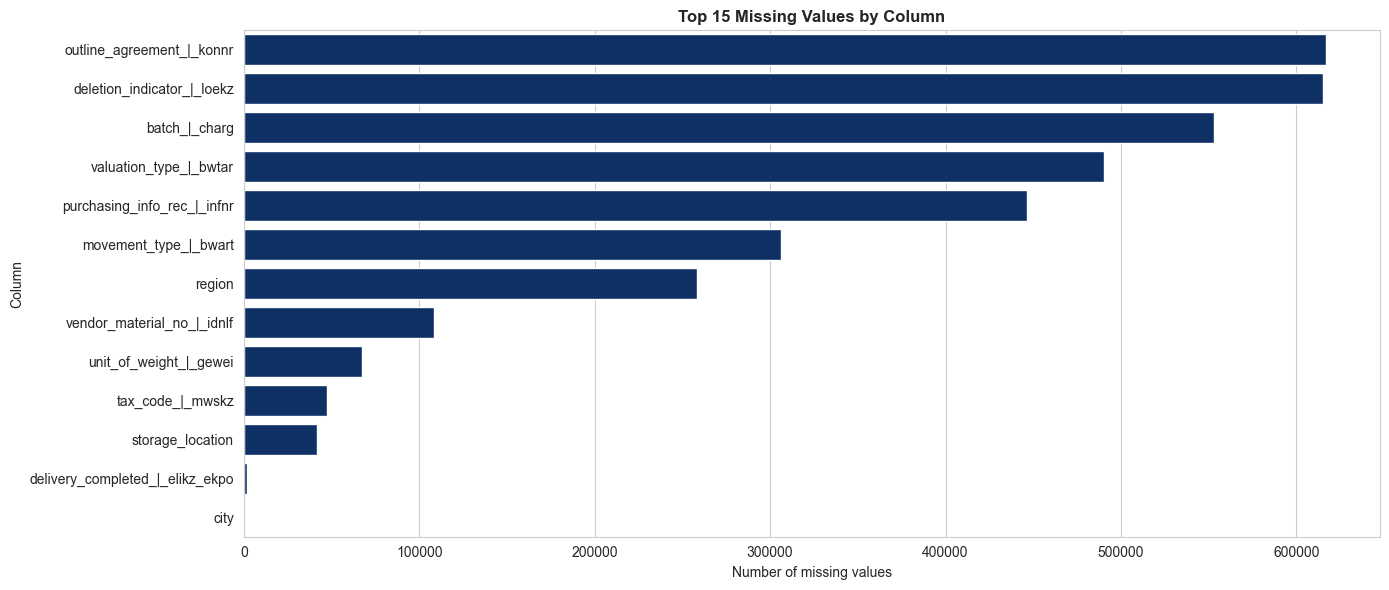

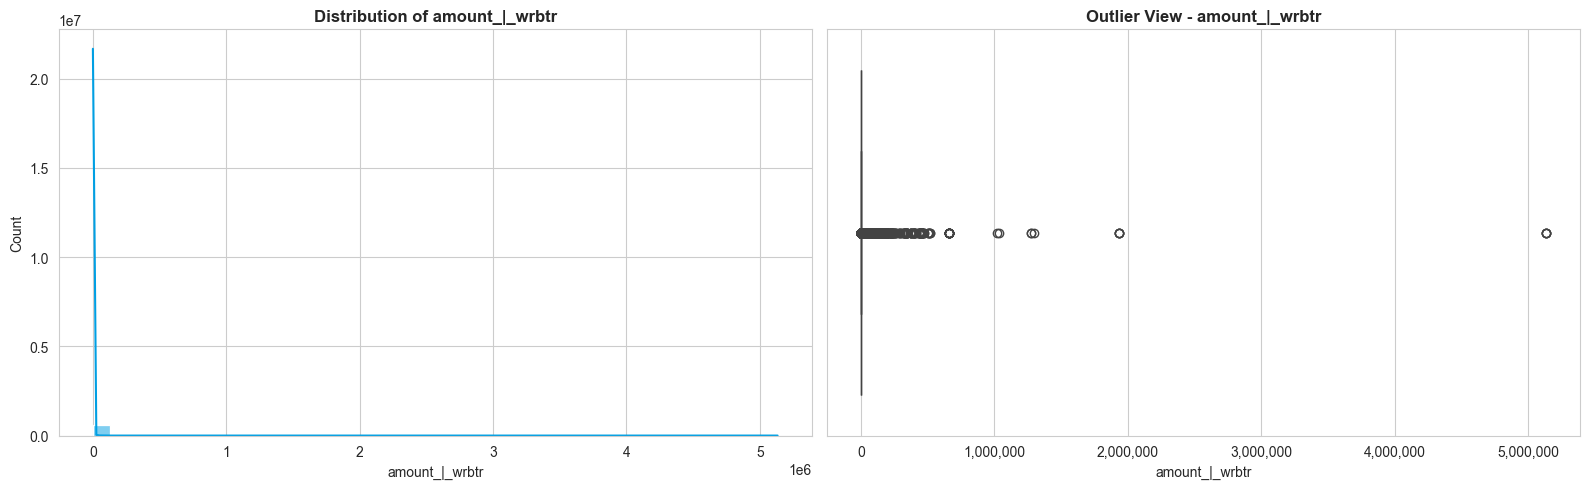

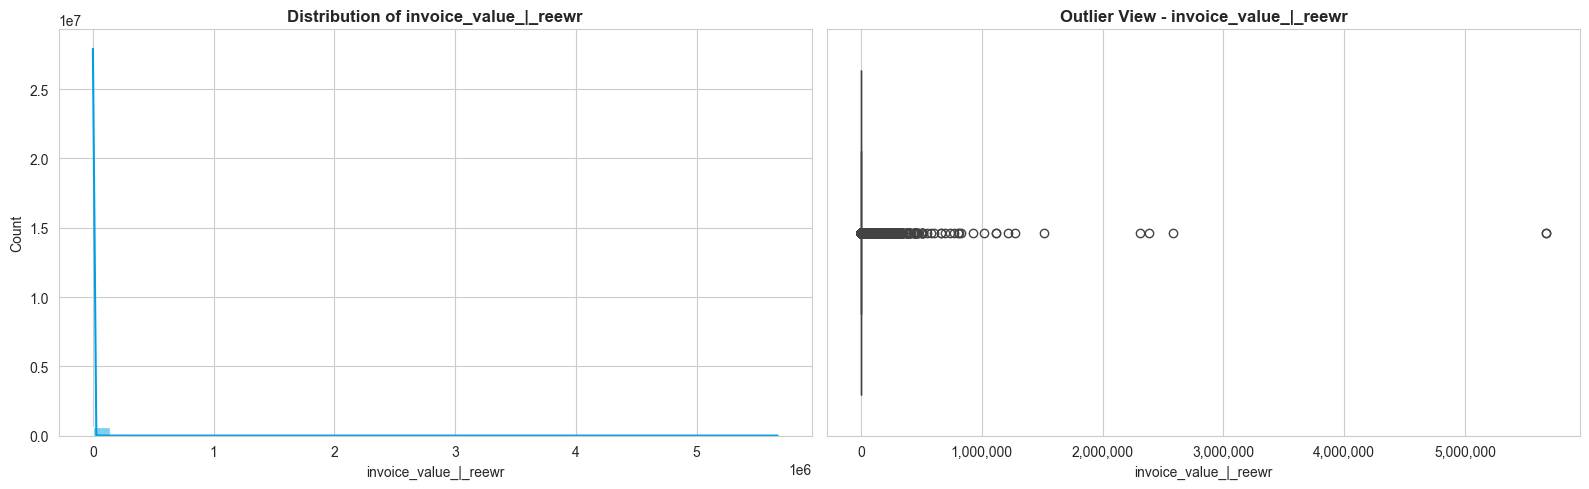

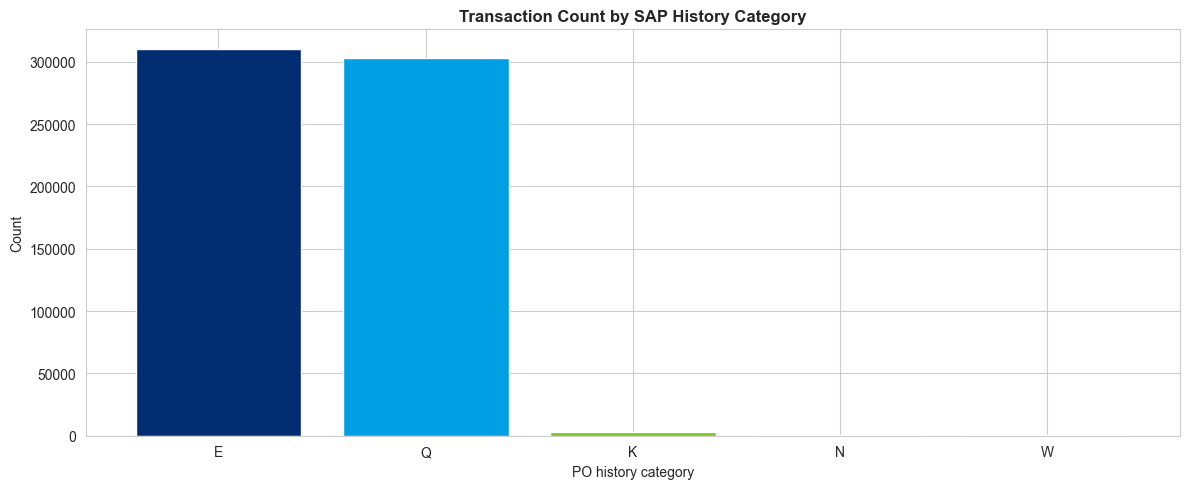

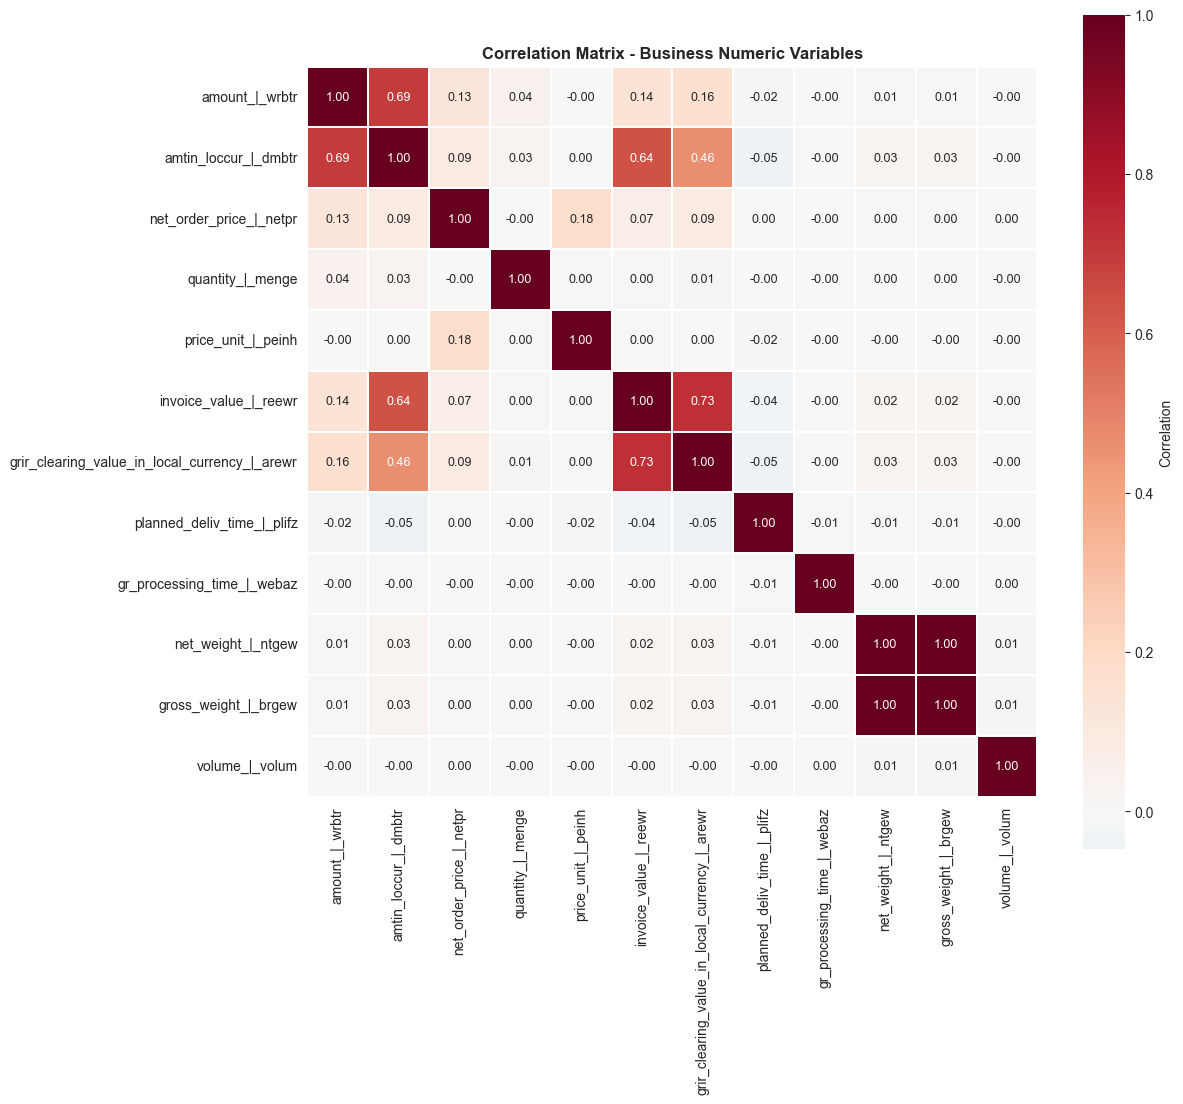


💡 Interpretation hints:
- Missing values show where data quality issues can affect modeling.
- Histograms and boxplots highlight skewness and outliers in monetary fields.
- The correlation matrix helps detect redundant or strongly linked variables.


In [8]:
# EDA visuals: distributions, category breakdowns, and correlation matrix
import matplotlib.ticker as mticker

eda_numeric_cols = [
    col for col in ['amount_|_wrbtr', 'invoice_value_|_reewr']
    if col in df.columns
]

print("\n📊 EDA OVERVIEW")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Selected monetary columns: {len(eda_numeric_cols)}")

# 1) Missing values overview
missing_cols = df.isna().sum().sort_values(ascending=False)
missing_cols = missing_cols[missing_cols > 0].head(15)

if not missing_cols.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(x=missing_cols.values, y=missing_cols.index, color=FORVIA_COLORS[0])
    plt.title("Top 15 Missing Values by Column", fontweight="bold")
    plt.xlabel("Number of missing values")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

# 2) Distribution of monetary amounts
for col in eda_numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    series = pd.to_numeric(df[col], errors='coerce').dropna()

    sns.histplot(series, bins=40, kde=True, ax=axes[0], color=FORVIA_COLORS[1])
    axes[0].set_title(f"Distribution of {col}", fontweight="bold")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    sns.boxplot(x=series, ax=axes[1], color=FORVIA_COLORS[2])
    axes[1].set_title(f"Outlier View - {col}", fontweight="bold")
    axes[1].set_xlabel(col)
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))

    plt.tight_layout()
    plt.show()

# 3) Key business categories
if 'po_history_category_|_bewtp' in df.columns:
    category_counts = df['po_history_category_|_bewtp'].value_counts().reset_index()
    category_counts.columns = ['po_history_category_|_bewtp', 'count']
    colors = FORVIA_COLORS[:len(category_counts)]

    plt.figure(figsize=(12, 5))
    plt.bar(category_counts['po_history_category_|_bewtp'], category_counts['count'], color=colors)
    plt.title("Transaction Count by SAP History Category", fontweight="bold")
    plt.xlabel("PO history category")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# 4) Correlation matrix on business numeric features only
candidate_metrics = [
    'amount_|_wrbtr',
    'amtin_loccur_|_dmbtr',
    'net_order_price_|_netpr',
    'quantity_|_menge',
    'price_unit_|_peinh',
    'invoice_value_|_reewr',
    'grir_clearing_value_in_local_currency_|_arewr',
    'planned_deliv_time_|_plifz',
    'gr_processing_time_|_webaz',
    'net_weight_|_ntgew',
    'gross_weight_|_brgew',
    'volume_|_volum',
]

corr_cols = [col for col in candidate_metrics if col in df.columns]
correlation_df = df[corr_cols].apply(pd.to_numeric, errors='coerce')
correlation_df = correlation_df.loc[:, correlation_df.nunique(dropna=True) > 1]

if correlation_df.shape[1] >= 2:
    corr = correlation_df.corr(numeric_only=True)
    plt.figure(figsize=(min(14, 1 + 0.95 * corr.shape[1]), min(12, 1 + 0.85 * corr.shape[0])))
    sns.heatmap(
        corr,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 9},
        square=True,
        linewidths=0.3,
        cbar_kws={'label': 'Correlation'}
    )
    plt.title("Correlation Matrix - Business Numeric Variables", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough business numeric columns to build a correlation matrix.")

# 5) Quick interpretation hints
print("\n💡 Interpretation hints:")
print("- Missing values show where data quality issues can affect modeling.")
print("- Histograms and boxplots highlight skewness and outliers in monetary fields.")
print("- The correlation matrix helps detect redundant or strongly linked variables.")

## 8️⃣ STATISTICAL PROFILE & DATA QUALITY DEEP DIVE

Cette section reste dans le périmètre du **Data Understanding**. Elle complète l’EDA existante avec une lecture statistique plus robuste des variables métier SAP P2P, afin d’identifier les distributions atypiques, les valeurs extrêmes et les signaux faibles utiles pour la suite du projet.


📐 STATISTICAL PROFILE OF KEY NUMERIC VARIABLES


,column,count,missing_rate,zero_rate,negative_rate,mean,median,std,min,max,skewness,kurtosis,iqr,mad,z_outlier_rate,iqr_outlier_rate
1,invoice_value_|_reewr,616800,0.00%,50.78%,0.00%,"1,524.92",0.00,"15,516.47",0.00,"5,669,888.33",187.78,"61,267.79",273.00,0.00,0.50%,17.27%
5,grir_clearing_value_in_local_currency_|_arewr,616800,0.00%,50.42%,0.00%,"1,522.17",0.00,"12,006.34",0.00,"2,582,768.61",68.20,"10,125.48",280.00,0.00,0.72%,17.20%
3,net_order_price_|_netpr,616800,0.00%,0.00%,0.00%,564.43,37.87,"8,219.61",0.01,"2,964,150.00",194.53,"60,349.65",181.56,35.17,0.25%,15.13%
4,amtin_loccur_|_dmbtr,616800,0.00%,1.39%,0.00%,"3,098.46",275.23,"24,163.65",0.00,"5,669,888.33",124.35,"24,582.67","1,224.06",254.60,0.49%,14.94%
2,quantity_|_menge,616800,0.00%,0.94%,0.00%,77.20,5.00,"5,485.74",0.00,"3,000,000.00",530.73,"290,001.19",13.00,4.00,0.04%,14.35%
0,amount_|_wrbtr,616800,0.00%,1.39%,0.00%,"1,639.99",230.00,"16,380.03",0.00,"5,132,640.00",216.81,"64,032.00",849.00,209.09,0.26%,13.47%


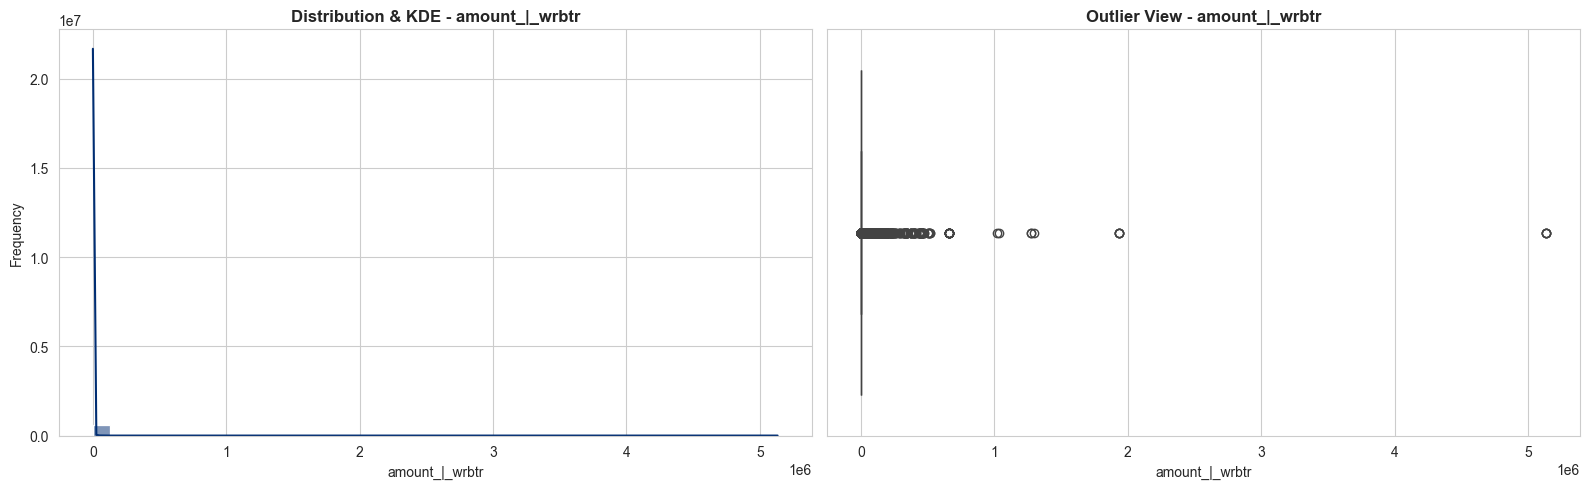


**Lecture métier - `amount_|_wrbtr`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : distribution asymétrique, outliers potentiels.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.


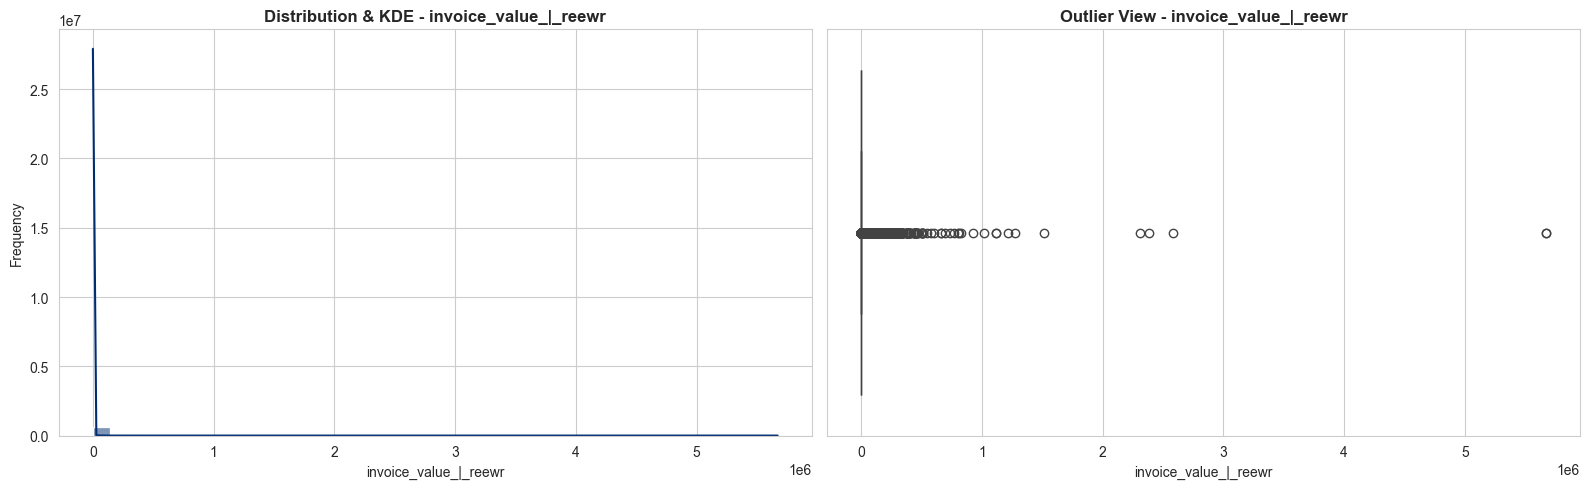


**Lecture métier - `invoice_value_|_reewr`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : distribution asymétrique, outliers potentiels, valeurs nulles fréquentes.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.


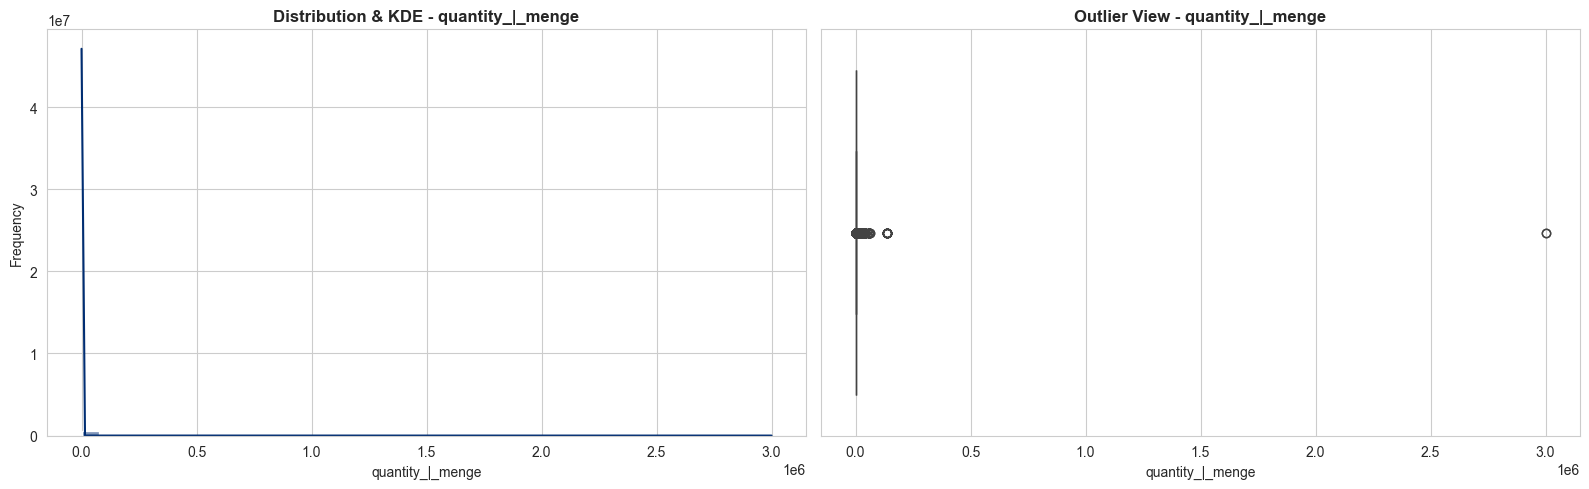


**Lecture métier - `quantity_|_menge`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : distribution asymétrique, outliers potentiels.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.



🔎 STATISTICAL TAKEAWAYS
- Variables with the strongest asymmetry should be transformed carefully before modeling.
- The IQR and Z-score outlier rates provide a first proxy for suspicious monetary or quantity observations.
- MAD is preferred for robust scaling when SAP data contains extreme business events.

Top skewed variables:


,column,skewness,iqr_outlier_rate,z_outlier_rate
2,quantity_|_menge,530.73,14.35%,0.04%
0,amount_|_wrbtr,216.81,13.47%,0.26%
3,net_order_price_|_netpr,194.53,15.13%,0.25%


In [9]:
from IPython.display import Markdown
from scipy import stats

# Helper functions for robust exploratory analysis

def find_available_columns(candidates):
    """Return the subset of candidate columns that exist in the current dataset."""
    return [col for col in candidates if col in df.columns]


def safe_numeric_series(column_name):
    """Convert a column to numeric safely and drop missing values."""
    return pd.to_numeric(df[column_name], errors='coerce').dropna()


def describe_numeric_series(series):
    """Compute robust statistical descriptors useful for Data Understanding."""
    if series.empty:
        return None

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    mad = (series - series.median()).abs().median()
    mean = series.mean()
    std = series.std(ddof=1)
    z_scores = np.abs(stats.zscore(series, nan_policy='omit')) if len(series) > 2 else np.array([])
    z_outlier_rate = float((z_scores > 3).mean()) if len(z_scores) else 0.0
    iqr_outlier_rate = float(((series < (q1 - 1.5 * iqr)) | (series > (q3 + 1.5 * iqr))).mean()) if iqr > 0 else 0.0

    return {
        'count': int(series.shape[0]),
        'mean': mean,
        'median': series.median(),
        'std': std,
        'min': series.min(),
        'max': series.max(),
        'skewness': series.skew(),
        'kurtosis': series.kurtosis(),
        'iqr': iqr,
        'mad': mad,
        'missing_rate': 0.0,
        'zero_rate': float((series == 0).mean()),
        'negative_rate': float((series < 0).mean()),
        'z_outlier_rate': z_outlier_rate,
        'iqr_outlier_rate': iqr_outlier_rate,
    }


def build_business_commentary(column_name, metrics):
    """Generate a concise business interpretation for each explored variable."""
    notes = []
    if abs(metrics['skewness']) > 1:
        notes.append("distribution asymétrique")
    if metrics['iqr_outlier_rate'] > 0.05 or metrics['z_outlier_rate'] > 0.02:
        notes.append("outliers potentiels")
    if metrics['negative_rate'] > 0:
        notes.append("valeurs négatives à contrôler")
    if metrics['zero_rate'] > 0.05:
        notes.append("valeurs nulles fréquentes")

    note_text = ", ".join(notes) if notes else "pas de signal statistique majeur visible"

    return Markdown(f"""
**Lecture métier - `{column_name}`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : {note_text}.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.
""")


stat_candidates = find_available_columns([
    'amount_|_wrbtr',
    'invoice_value_|_reewr',
    'quantity_|_menge',
    'net_order_price_|_netpr',
    'amtin_loccur_|_dmbtr',
    'grir_clearing_value_in_local_currency_|_arewr',
])

if stat_candidates:
    stats_rows = []
    for column_name in stat_candidates:
        series = safe_numeric_series(column_name)
        metrics = describe_numeric_series(series)
        if metrics is None:
            continue
        metrics['column'] = column_name
        metrics['missing_rate'] = float(df[column_name].isna().mean())
        stats_rows.append(metrics)

    stats_df = pd.DataFrame(stats_rows)
    stats_df = stats_df[[
        'column', 'count', 'missing_rate', 'zero_rate', 'negative_rate',
        'mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis',
        'iqr', 'mad', 'z_outlier_rate', 'iqr_outlier_rate'
    ]].sort_values(by='iqr_outlier_rate', ascending=False)

    print("\n📐 STATISTICAL PROFILE OF KEY NUMERIC VARIABLES")
    print("=" * 100)
    display(stats_df.style.format({
        'missing_rate': '{:.2%}',
        'zero_rate': '{:.2%}',
        'negative_rate': '{:.2%}',
        'mean': '{:,.2f}',
        'median': '{:,.2f}',
        'std': '{:,.2f}',
        'min': '{:,.2f}',
        'max': '{:,.2f}',
        'skewness': '{:,.2f}',
        'kurtosis': '{:,.2f}',
        'iqr': '{:,.2f}',
        'mad': '{:,.2f}',
        'z_outlier_rate': '{:.2%}',
        'iqr_outlier_rate': '{:.2%}',
    }))

    focus_columns = stat_candidates[:3]
    for column_name in focus_columns:
        series = safe_numeric_series(column_name)
        if series.empty:
            continue

        metrics = describe_numeric_series(series)
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        sns.histplot(series, kde=True, bins=40, color=FORVIA_COLORS[0], ax=axes[0])
        axes[0].set_title(f"Distribution & KDE - {column_name}", fontweight='bold')
        axes[0].set_xlabel(column_name)
        axes[0].set_ylabel("Frequency")

        sns.boxplot(x=series, color=FORVIA_COLORS[2], ax=axes[1])
        axes[1].set_title(f"Outlier View - {column_name}", fontweight='bold')
        axes[1].set_xlabel(column_name)

        plt.tight_layout()
        plt.show()

        display(build_business_commentary(column_name, metrics))

    high_skew = stats_df.loc[stats_df['skewness'].abs().sort_values(ascending=False).index].head(3)
    print("\n🔎 STATISTICAL TAKEAWAYS")
    print("- Variables with the strongest asymmetry should be transformed carefully before modeling.")
    print("- The IQR and Z-score outlier rates provide a first proxy for suspicious monetary or quantity observations.")
    print("- MAD is preferred for robust scaling when SAP data contains extreme business events.")
    print("\nTop skewed variables:")
    display(high_skew[['column', 'skewness', 'iqr_outlier_rate', 'z_outlier_rate']].style.format({
        'skewness': '{:,.2f}',
        'iqr_outlier_rate': '{:.2%}',
        'z_outlier_rate': '{:.2%}',
    }))
else:
    print("No numeric business column found for advanced statistical profiling.")

## 9️⃣ SAP P2P BUSINESS EXPLORATION: GR / IR TIMING AND ANOMALIES

Cette partie reste exploratoire. Elle met l’accent sur les incohérences GR / IR visibles dans les données brutes, ainsi que sur les délais métier qui peuvent signaler des retards inhabituels, des écarts de processus ou des cas à investiguer plus tard dans la chaîne Data Preparation / Modeling.


⏱️ GR / IR TIMING ANALYSIS (AVEC VRAI NOM FOURNISSEUR)
Items with both GR and IR dates: 283,027
Average delay: 10.81 days
Median delay: 5.00 days
% > 30 days: 6.73%
% negative delays: 0.67%



Top 15 suppliers:


,supplier_name,count_items,avg_delay,median_delay,pct_delay_gt_30,pct_negative
0,MABEO INDUSTRIES,15409,10.567461,7.0,0.031280,0.0
1,"KROK CZ, S.R.O.",10188,13.487240,8.0,0.090793,0.0
2,RUBIX FRANCE,8651,6.611837,4.0,0.020344,0.0
3,URVINAPOR,5927,22.210562,11.0,0.215792,0.0
4,ARTWELD S R O,5844,2.526694,1.0,0.007871,0.0
5,DAYTON PROGRESS,5734,25.608476,7.0,0.207883,0.0
6,CP TRADE LODZ SP. Z O.O.,4473,11.631344,2.0,0.104628,0.0
7,OŚRODEK USŁUG TECHNICZNYCH MEZAR SP,4054,13.925752,12.0,0.026394,0.0
8,‼DUSICKA JAROSLAV KOV. (USE_259448),3926,16.657412,14.0,0.141111,0.0
9,MX NORM SP. Z O.O.,3744,4.250534,1.0,0.009882,0.0


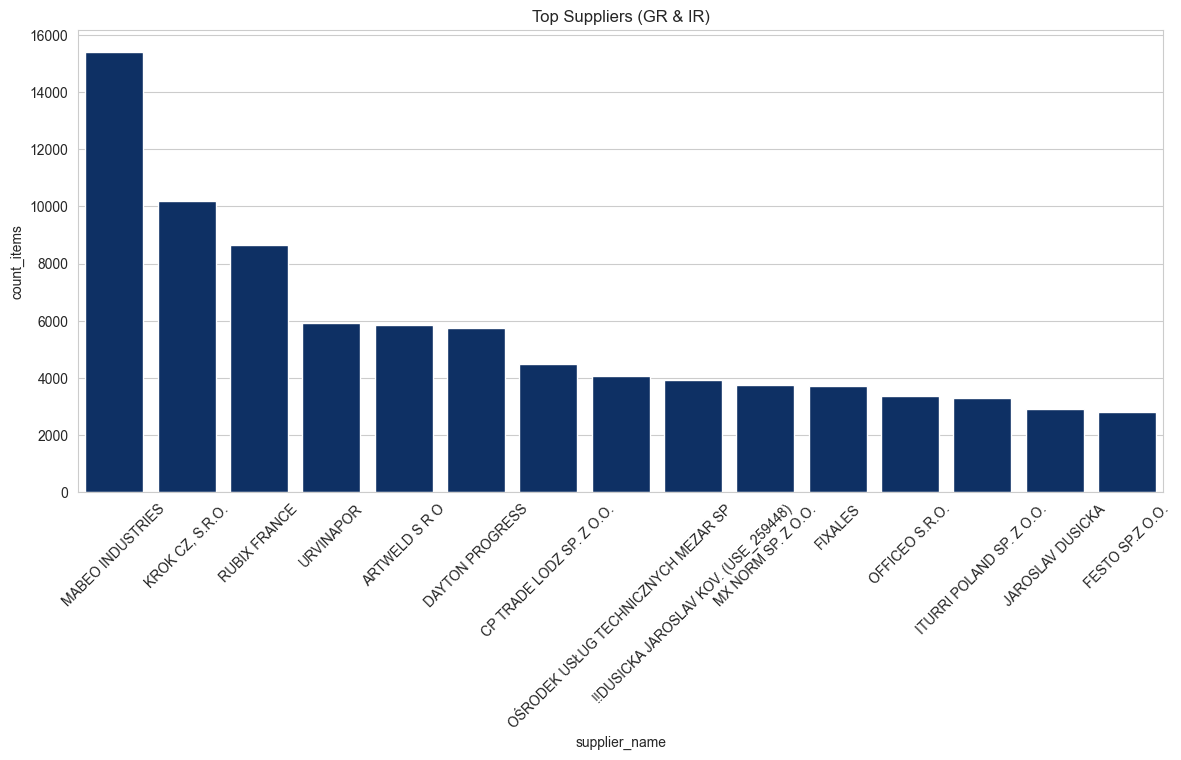

In [10]:
# SAP P2P timing and anomaly exploration
from IPython.display import Markdown

# Use posting date explicitly for GR / IR timing analysis
if 'posting_date_|_budat' in df.columns:
    business_df = df.copy()
    business_df['posting_date_|_budat'] = pd.to_datetime(business_df['posting_date_|_budat'], errors='coerce')

    # ✅ FORCER supplier_name dès le départ
    if 'supplier_name' not in business_df.columns:
        if 'name_1_|_name1' in business_df.columns:
            business_df['supplier_name'] = business_df['name_1_|_name1']
        elif 'supplier_|_lifnr' in business_df.columns:
            business_df['supplier_name'] = business_df['supplier_|_lifnr']

    # Build GR / IR flags
    if 'po_history_category_|_bewtp' in business_df.columns:
        business_df['event_type'] = business_df['po_history_category_|_bewtp'].astype(str).str.upper().str.strip()
        business_df['is_gr_event'] = business_df['event_type'] == 'E'
        business_df['is_ir_event'] = business_df['event_type'] == 'Q'
    else:
        business_df['is_gr_event'] = False
        business_df['is_ir_event'] = False

    key_cols = ['purchasing_document_|_ebeln', 'item_|_ebelp']

    if set(key_cols).issubset(business_df.columns):

        # ✅ GR dates
        gr_dates = (
            business_df[
                (business_df['is_gr_event']) & (business_df['posting_date_|_budat'].notna())
            ][key_cols + ['posting_date_|_budat']]
            .groupby(key_cols, as_index=False)['posting_date_|_budat']
            .min()
            .rename(columns={'posting_date_|_budat': 'first_gr_date'})
        )

        # ✅ IR dates
        ir_dates = (
            business_df[
                (business_df['is_ir_event']) & (business_df['posting_date_|_budat'].notna())
            ][key_cols + ['posting_date_|_budat']]
            .groupby(key_cols, as_index=False)['posting_date_|_budat']
            .min()
            .rename(columns={'posting_date_|_budat': 'first_ir_date'})
        )

        # ✅ merge GR / IR
        timing_df = gr_dates.merge(ir_dates, on=key_cols, how='outer')

        # ✅ compute delay
        timing_df['gr_ir_delay_days'] = (
            timing_df['first_ir_date'] - timing_df['first_gr_date']
        ).dt.days

        timing_df['delay_bucket'] = pd.cut(
            timing_df['gr_ir_delay_days'],
            bins=[-np.inf, -1, 0, 7, 30, 90, np.inf],
            labels=['Negative', 'Same day', '1-7 days', '8-30 days', '31-90 days', '90+ days']
        )

        # ✅ JOIN supplier_name propre
        supplier_map = (
            business_df[
                business_df['supplier_name'].notna()
            ][key_cols + ['supplier_name']]
            .drop_duplicates(subset=key_cols + ['supplier_name'])
            .groupby(key_cols, as_index=False)['supplier_name']
            .first()
        )

        timing_df = timing_df.merge(supplier_map, on=key_cols, how='left')

        # ===================================================
        # 📊 GLOBAL METRICS
        # ===================================================
        print("\n⏱️ GR / IR TIMING ANALYSIS (AVEC VRAI NOM FOURNISSEUR)")
        print("=" * 100)

        delay_series = timing_df['gr_ir_delay_days'].dropna()

        if not delay_series.empty:
            print(f"Items with both GR and IR dates: {delay_series.shape[0]:,}")
            print(f"Average delay: {delay_series.mean():.2f} days")
            print(f"Median delay: {delay_series.median():.2f} days")
            print(f"% > 30 days: {(delay_series > 30).mean():.2%}")
            print(f"% negative delays: {(delay_series < 0).mean():.2%}")

        # ===================================================
        # 📊 SUPPLIER AGGREGATION (CORRIGÉ)
        # ===================================================
        supplier_timing = timing_df.dropna(subset=['supplier_name', 'gr_ir_delay_days'])

        if not supplier_timing.empty:

            supplier_agg = (
                supplier_timing
                .groupby('supplier_name')
                .agg(
                    count_items=('gr_ir_delay_days', 'count'),
                    avg_delay=('gr_ir_delay_days', 'mean'),
                    median_delay=('gr_ir_delay_days', 'median'),
                    pct_delay_gt_30=('gr_ir_delay_days', lambda s: (s > 30).mean()),
                    pct_negative=('gr_ir_delay_days', lambda s: (s < 0).mean())
                )
                .reset_index()
                .sort_values(['count_items'], ascending=False)
                .reset_index(drop=True)  # ✅ propre index
            )

            print("\nTop 15 suppliers:")
            display(supplier_agg.head(15))

            # ✅ plot
            import matplotlib.pyplot as plt
            import seaborn as sns

            top15 = supplier_agg.head(15)

            plt.figure(figsize=(14, 6))
            sns.barplot(data=top15, x='supplier_name', y='count_items')
            plt.xticks(rotation=45)
            plt.title("Top Suppliers (GR & IR)")
            plt.show()

        else:
            print("No supplier data available")

    else:
        print("PO / item keys missing")

else:
    print("No posting_date_|_budat found")

## 10️⃣ SUPPLIER EXPLORATION FOR FUTURE RISK FEATURES

Cette section ne fait pas encore du clustering final. Elle sert à décrire les comportements fournisseurs visibles dans les données brutes, à identifier les concentrations de volume / montant, et à préparer les futures features qui seront utilisées plus tard dans le projet de Machine Learning.

In [11]:
# Supplier exploration for future risk features
from IPython.display import Markdown

# ✅ FORCER le bon champ fournisseur (priorité au nom)
if 'supplier_name' in df.columns:
    supplier_col = 'supplier_name'
elif 'name_1_|_name1' in df.columns:
    df['supplier_name'] = df['name_1_|_name1']
    supplier_col = 'supplier_name'
elif 'supplier_|_lifnr' in df.columns:
    supplier_col = 'supplier_|_lifnr'
else:
    supplier_col = None

if supplier_col:
    supplier_df = df.copy()

    # ✅ NORMALISER supplier_name (important)
    if supplier_col == 'supplier_|_lifnr' and 'supplier_name' in supplier_df.columns:
        supplier_df[supplier_col] = supplier_df['supplier_name'].fillna(supplier_df[supplier_col])

    # === Colonnes optionnelles ===
    amount_col = 'amount_|_wrbtr' if 'amount_|_wrbtr' in supplier_df.columns else None
    event_col = 'po_history_category_|_bewtp' if 'po_history_category_|_bewtp' in supplier_df.columns else None

    date_col = next(
        (col for col in ['posting_date_|_budat', 'document_date_|_bedat', 'entry_date_|_cpudt']
         if col in supplier_df.columns),
        None
    )

    if amount_col:
        supplier_df[amount_col] = pd.to_numeric(supplier_df[amount_col], errors='coerce')

    if date_col:
        supplier_df[date_col] = pd.to_datetime(supplier_df[date_col], errors='coerce')

    # ✅ GROUP BY FOURNISSEUR (VRAI NOM)
    supplier_profile = supplier_df.groupby(supplier_col).agg(
        transaction_count=(supplier_col, 'size'),
        distinct_po_count=('purchasing_document_|_ebeln', 'nunique') if 'purchasing_document_|_ebeln' in supplier_df.columns else (supplier_col, 'size'),
        total_amount=(amount_col, 'sum') if amount_col else (supplier_col, 'size'),
        avg_amount=(amount_col, 'mean') if amount_col else (supplier_col, 'size'),
        median_amount=(amount_col, 'median') if amount_col else (supplier_col, 'size'),
        std_amount=(amount_col, 'std') if amount_col else (supplier_col, 'size'),
    ).reset_index()

    # ✅ FEATURES FINANCIÈRES
    if amount_col:
        supplier_profile['zero_amount_rate'] = supplier_df.groupby(supplier_col)[amount_col].apply(lambda s: (s == 0).mean()).values
        supplier_profile['negative_amount_rate'] = supplier_df.groupby(supplier_col)[amount_col].apply(lambda s: (s < 0).mean()).values
        supplier_profile['amount_volatility'] = supplier_profile['std_amount'] / supplier_profile['avg_amount'].abs().replace(0, np.nan)

    # ✅ FEATURES P2P
    if event_col:
        supplier_profile['gr_share'] = supplier_df.groupby(supplier_col)[event_col].apply(lambda s: (s.astype(str).str.upper() == 'E').mean()).values
        supplier_profile['ir_share'] = supplier_df.groupby(supplier_col)[event_col].apply(lambda s: (s.astype(str).str.upper() == 'Q').mean()).values
        supplier_profile['history_imbalance'] = (supplier_profile['gr_share'].fillna(0) - supplier_profile['ir_share'].fillna(0)).abs()
    else:
        supplier_profile[['gr_share', 'ir_share', 'history_imbalance']] = np.nan

    # ✅ ACTIVITÉ TEMPORELLE
    if date_col:
        supplier_profile['active_months'] = supplier_df.groupby(supplier_col)[date_col].apply(
            lambda s: s.dt.to_period('M').nunique()
        ).values
    else:
        supplier_profile['active_months'] = np.nan

    # ✅ PROXY RISQUE
    proxy_cols = ['negative_amount_rate', 'zero_amount_rate', 'amount_volatility', 'history_imbalance']

    proxy_components = [
        supplier_profile[c].rank(pct=True).fillna(0)
        for c in proxy_cols if c in supplier_profile.columns
    ]

    supplier_profile['exploratory_risk_proxy'] = (
        sum(proxy_components) / len(proxy_components)
        if proxy_components else 0.0
    )

    supplier_profile['amount_share'] = supplier_profile['total_amount'] / supplier_profile['total_amount'].sum()

    supplier_profile = supplier_profile.sort_values(
        ['exploratory_risk_proxy', 'total_amount'],
        ascending=[False, False]
    )

    print("\n👥 SUPPLIER EXPLORATION PROFILE (CORRIGÉ)")
    print("=" * 100)

    display(supplier_profile.head(15).style.format({
        'total_amount': '{:,.2f}',
        'avg_amount': '{:,.2f}',
        'median_amount': '{:,.2f}',
        'std_amount': '{:,.2f}',
        'zero_amount_rate': '{:.2%}',
        'negative_amount_rate': '{:.2%}',
        'amount_volatility': '{:.2f}',
        'gr_share': '{:.2%}',
        'ir_share': '{:.2%}',
        'history_imbalance': '{:.2%}',
        'active_months': '{:,.0f}',
        'exploratory_risk_proxy': '{:.2f}',
        'amount_share': '{:.2%}',
    }))

else:
    print('❌ No supplier column found')


👥 SUPPLIER EXPLORATION PROFILE (CORRIGÉ)


,supplier_name,transaction_count,distinct_po_count,total_amount,avg_amount,median_amount,std_amount,zero_amount_rate,negative_amount_rate,amount_volatility,gr_share,ir_share,history_imbalance,active_months,exploratory_risk_proxy,amount_share
1037,JENDAMARK AUTOMATION (PTY) LTD,84,20,"358,186.75","4,264.13",0.00,"13,477.32",79.76%,0.00%,3.16,89.29%,10.71%,78.57%,13,0.86,0.04%
1088,KIVNON FRANCE,12,6,966.00,80.50,0.00,183.19,66.67%,0.00%,2.28,83.33%,16.67%,66.67%,3,0.86,0.00%
670,FAURECIA EXHAUST SYSTEMS S.R.O.,59,2,"10,518.79",178.28,0.00,392.73,64.41%,0.00%,2.20,66.10%,1.69%,64.41%,4,0.86,0.00%
1464,PERIFERI,40,13,"19,682.00",492.05,0.00,917.17,60.00%,0.00%,1.86,80.00%,20.00%,60.00%,3,0.85,0.00%
2234,‼FEINTOOL TECHNOLOGIE (USE_258560),91,9,"140,509.93","1,544.07",33.32,"4,463.85",29.67%,0.00%,2.89,53.85%,24.18%,29.67%,12,0.85,0.01%
394,CLE DE 13 PRODUCTIQUE,17,13,"7,268.08",427.53,0.00,809.74,52.94%,0.00%,1.89,76.47%,23.53%,52.94%,10,0.85,0.00%
1568,QUAKER HOUGHTON SALES BV,119,37,"6,835,766.04","57,443.41","1,964.60","182,834.17",15.13%,0.00%,3.18,59.66%,35.29%,24.37%,23,0.84,0.68%
1842,SINTRON INDUSTRIE-ELEKTRIK GMBH,3,2,481.80,160.60,21.00,260.19,33.33%,0.00%,1.62,100.00%,0.00%,100.00%,1,0.84,0.00%
1213,LÉKÁRNA U SOUDU S.R.O.,41,5,"46,303.72","1,129.36",150.00,"2,665.52",21.95%,0.00%,2.36,60.98%,39.02%,21.95%,3,0.84,0.00%
1588,RD TECHNOLOGIES SAS,30,16,"292,585.61","9,752.85",264.00,"22,549.79",26.67%,0.00%,2.31,60.00%,40.00%,20.00%,13,0.84,0.03%


## 1️⃣1️⃣ ANALYSE DES RELATIONS ENTRE VARIABLES & DETECTION DES PROBLEMES (Rapport §3.3.2 / §3.3.3)

Cette section exploite le **dataset de features enrichies** (niveau PO + Item,
issu de la Feature Engineering / Phase 2 Risk Scoring) afin de couvrir les
deux sous-sections du memoire :

- **3.3.2 Analyse des relations entre variables** : matrice de correlation,
  scatter plots cibles, benchmark des correlations.
- **3.3.3 Detection des problemes potentiels** : valeurs aberrantes,
  distribution asymetrique des montants, valeurs manquantes / completude
  GR-IR, desequilibre des classes, doublons / mouvements multiples, et
  controle des formats de dates.

Toutes les figures sont enregistrees en haute resolution (300 dpi) dans
`src/docs/figures/<sous-dossier>/`, avec une interpretation generee
automatiquement a partir des resultats reellement obtenus.


### Setup - Chargement du dataset de features et mapping des variables

Le dataset brut charge en debut de notebook (`df`, issu de `Documents1.csv`)
est au niveau ligne de mouvement SAP (GR/IR) et ne contient pas directement
les variables agregees demandees par le rapport (`GR Amount`, `IR Amount`,
`Total Quantity`, `Amount Per Qty`, `Aging Days`, `Risk Score`, `Delivery Gap`,
`Invoice Gap`).

La cellule ci-dessous charge donc le dataset de features au niveau
**(PO, Item)** produit par la Feature Engineering / Phase 2 Risk Scoring
(`documents_with_labels_and_features_features_20260525_162427.csv` +
`p2p_ml_dataset.csv` pour le `Risk Score`), construit un mapping explicite
entre les noms de variables du rapport et les colonnes reellement
disponibles, et derive le statut de transaction (`OK`,
`DELIVERED_NOT_INVOICED`, `INVOICED_NOT_DELIVERED`, `INCOMPLETE`) a partir des
indicateurs `has_gr` / `has_ir` deja utilises plus haut dans ce notebook.

Toute colonne demandee mais absente est detectee automatiquement, mappee vers
l'equivalent le plus proche disponible, et signalee dans le recapitulatif
final - sans provoquer d'erreur.


In [12]:
# Setup: load the feature-engineered transaction dataset (PO + Item level)
# and build the variable mapping used throughout Section 11.
from pathlib import Path
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
from config import PROCESSED_DATA_DIR, FIGURE_DPI

# --- Figure output directories ------------------------------------------
FIGURES_ROOT = project_root / 'src' / 'docs' / 'figures'
FIG_SUBDIRS = ['correlation', 'scatterplots', 'outliers', 'distributions',
                'missing_values', 'class_distribution', 'duplicates', 'dates', 'benchmarks']
FIG_DIRS = {name: FIGURES_ROOT / name for name in FIG_SUBDIRS}
for d in FIG_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

def savefig(fig, subdir, filename):
    """Save a matplotlib figure at 300 dpi under src/docs/figures/<subdir>/<filename>."""
    path = FIG_DIRS[subdir] / filename
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f"  [OK] Figure saved -> {path.relative_to(project_root)}")
    return path

def corr_strength(r):
    """Qualitative label for a Pearson correlation coefficient."""
    a = abs(r)
    if a >= 0.8:
        return "tres forte"
    if a >= 0.6:
        return "forte"
    if a >= 0.4:
        return "moderee"
    if a >= 0.2:
        return "faible"
    return "negligeable"

# --- Load the feature-engineered transaction dataset (PO + Item level) ---
FEATURES_FILE = PROCESSED_DATA_DIR / 'documents_with_labels_and_features_features_20260525_162427.csv'
RISK_FILE = PROCESSED_DATA_DIR / 'p2p_ml_dataset.csv'

feat_df = pd.read_csv(FEATURES_FILE, low_memory=False)
print(f"Feature dataset loaded: {feat_df.shape[0]:,} rows x {feat_df.shape[1]} columns")
print(f"Source: {FEATURES_FILE.relative_to(project_root)}")

# Attach the transaction-level risk score computed in Phase 2 (same pipeline
# run -> identical row order). We verify the alignment on a shared numeric
# column (total_gr_amount) before merging, and fall back gracefully if it
# does not match.
if RISK_FILE.exists():
    risk_df = pd.read_csv(RISK_FILE, usecols=['total_gr_amount', 'risk_score_transaction'], low_memory=False)
    aligned = (len(risk_df) == len(feat_df)) and np.allclose(
        feat_df['total_gr_amount'].fillna(-1).values,
        risk_df['total_gr_amount'].fillna(-1).values,
        atol=1e-2,
    )
    if aligned:
        feat_df['risk_score'] = risk_df['risk_score_transaction'].values
        print("Risk Score merged from p2p_ml_dataset.csv (row alignment verified on total_gr_amount).")
    else:
        feat_df['risk_score'] = np.nan
        print("Risk Score NOT merged: row alignment check failed, column will be skipped.")
else:
    feat_df['risk_score'] = np.nan
    print(f"Risk Score NOT merged: {RISK_FILE.name} not found.")

# Derive the business transaction status from the has_gr / has_ir flags
# (same logic as the GR/IR combination analysis above), matching the
# OK / DELIVERED_NOT_INVOICED / INVOICED_NOT_DELIVERED / INCOMPLETE
# categories defined in config.ANOMALY_TYPES.
status_conditions = [
    (feat_df['has_gr'] == 1) & (feat_df['has_ir'] == 1),
    (feat_df['has_gr'] == 1) & (feat_df['has_ir'] == 0),
    (feat_df['has_gr'] == 0) & (feat_df['has_ir'] == 1),
]
status_choices = ['OK', 'DELIVERED_NOT_INVOICED', 'INVOICED_NOT_DELIVERED']
feat_df['transaction_status'] = np.select(status_conditions, status_choices, default='INCOMPLETE')

# --- Conceptual column mapping used in the report (section 3.3.2 / 3.3.3) -
# Some report variable names do not exist verbatim in the dataset; the
# closest equivalent engineered feature is used instead and documented here.
COLUMN_MAP = {
    'Amount':           ('amount_|_wrbtr_sum', 'Montant total de la ligne PO (identique a GR Amount ici)'),
    'GR Amount':        ('gr_amount',          'Montant receptionne (Goods Receipt)'),
    'IR Amount':        ('ir_amount',          'Montant facture (Invoice Receipt)'),
    'Total Quantity':   ('total_quantity',     'Quantite totale receptionnee'),
    'Amount Per Qty':   ('amount_per_qty',     'Montant unitaire (GR Amount / Total Quantity)'),
    'Aging Days':       ('days_in_system',     'Anciennete de la transaction (jours depuis creation)'),
    'Risk Score':       ('risk_score',         'Score de risque transactionnel (Phase 2)'),
    'Delivery Gap':     ('gr_ir_difference',   'Proxy: ecart de montant IR - GR (gr_ir_difference)'),
    'Invoice Gap':      ('gr_ir_gap_pct',      'Proxy: ecart relatif GR/IR en % (gr_ir_gap_pct)'),
    'Transaction Status': ('transaction_status', 'Statut derive de has_gr / has_ir'),
}

resolved_map, missing_map = {}, []
for label, (col, desc) in COLUMN_MAP.items():
    if col in feat_df.columns:
        resolved_map[label] = col
    else:
        missing_map.append((label, col, desc))

eda_df = feat_df.rename(columns={col: label for label, col in resolved_map.items()})[list(resolved_map.keys())].copy()

print("\nCOLUMN MAPPING - SECTION 11 (report variables -> dataset columns)")
print("=" * 80)
for label, (col, desc) in COLUMN_MAP.items():
    status = "OK" if label in resolved_map else "MISSING"
    print(f"  [{status:7s}] {label:20s} <- {col:22s} | {desc}")

if missing_map:
    print("\nNote: the columns above marked MISSING were not found and were skipped automatically.")

print(f"\neda_df ready: {eda_df.shape[0]:,} rows x {eda_df.shape[1]} columns")

Feature dataset loaded: 294,722 rows x 58 columns
Source: src\data\processed\documents_with_labels_and_features_features_20260525_162427.csv


Risk Score merged from p2p_ml_dataset.csv (row alignment verified on total_gr_amount).

COLUMN MAPPING - SECTION 11 (report variables -> dataset columns)
  [OK     ] Amount               <- amount_|_wrbtr_sum     | Montant total de la ligne PO (identique a GR Amount ici)
  [OK     ] GR Amount            <- gr_amount              | Montant receptionne (Goods Receipt)
  [OK     ] IR Amount            <- ir_amount              | Montant facture (Invoice Receipt)
  [OK     ] Total Quantity       <- total_quantity         | Quantite totale receptionnee
  [OK     ] Amount Per Qty       <- amount_per_qty         | Montant unitaire (GR Amount / Total Quantity)
  [OK     ] Aging Days           <- days_in_system         | Anciennete de la transaction (jours depuis creation)
  [OK     ] Risk Score           <- risk_score             | Score de risque transactionnel (Phase 2)
  [OK     ] Delivery Gap         <- gr_ir_difference       | Proxy: ecart de montant IR - GR (gr_ir_difference)
  [OK     ]

## Partie 1 - Matrice de correlation (Rapport 3.3.2)

Cette heatmap presente les coefficients de **correlation de Pearson** entre les
principales variables numeriques SAP P2P : `Amount`, `GR Amount`, `IR Amount`,
`Total Quantity`, `Amount Per Qty`, `Aging Days`, `Risk Score`, `Delivery Gap`
et `Invoice Gap`. Elle permet de :

- mettre en evidence les variables redondantes (forte correlation positive) ;
- detecter les relations inverses (correlation negative) utiles pour la
  comprehension metier (ex. volume vs cout unitaire) ;
- preparer la selection de variables pour les phases suivantes (feature
  engineering / modelisation).

La figure est enregistree dans `src/docs/figures/correlation/correlation_matrix.png`.


  [OK] Figure saved -> src\docs\figures\correlation\correlation_matrix.png


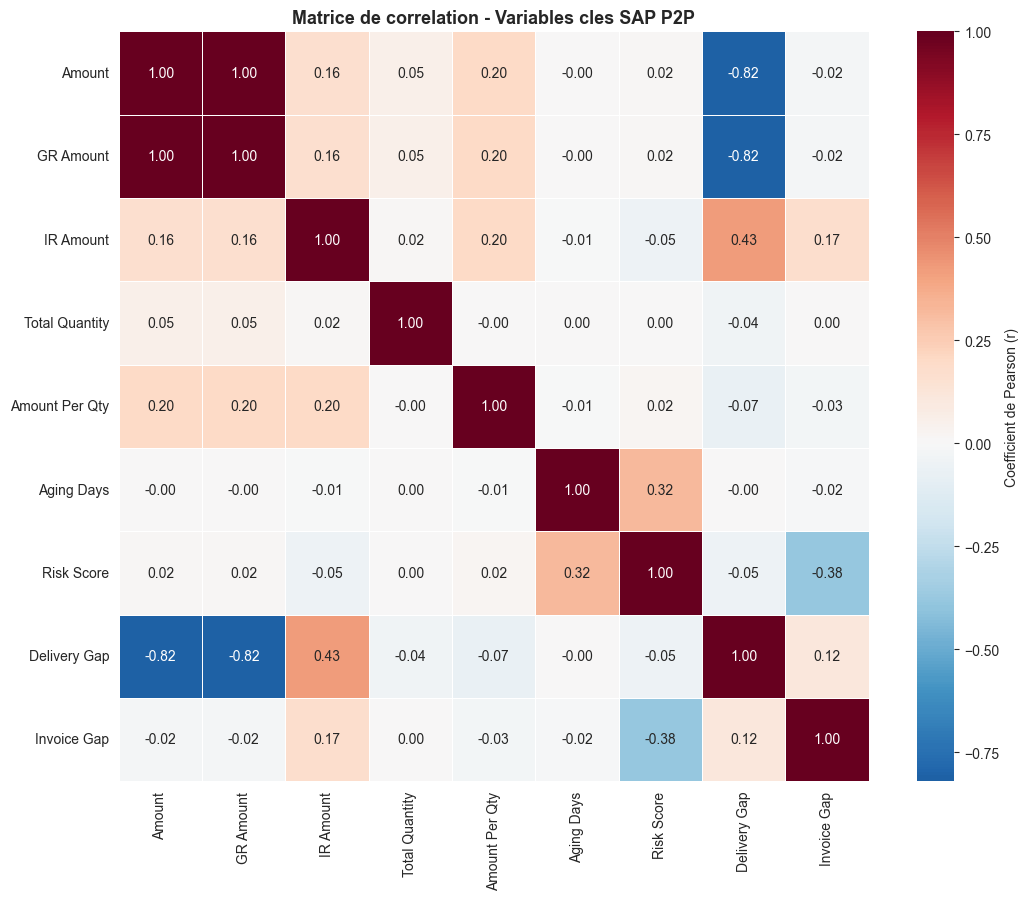


INTERPRETATION - Matrice de correlation
- GR Amount vs IR Amount : r = 0.163 (correlation negligeable). Le lien entre montant receptionne et montant facture reste limite, ce qui traduit la part importante de lignes partiellement facturees ou en attente de facturation.
- Aging Days vs Risk Score : r = 0.322 (correlation faible, positive). Les transactions les plus anciennes tendent a porter un score de risque plus eleve, ce qui confirme l'effet d'anciennete integre dans le moteur de scoring.
- Total Quantity vs Amount Per Qty : r = -0.002 (correlation negligeable). Le signe negatif attendu (effet de volume) est present mais quasi nul ici : le cout unitaire ne diminue pas mecaniquement avec la quantite commandee dans ce jeu de donnees.

- Paire la plus fortement correlee (hors diagonale) : Amount <-> GR Amount (r = 1.000).


In [13]:
# Pearson correlation matrix of key SAP P2P numeric variables
corr_vars = [c for c in ['Amount', 'GR Amount', 'IR Amount', 'Total Quantity',
                          'Amount Per Qty', 'Aging Days', 'Risk Score',
                          'Delivery Gap', 'Invoice Gap'] if c in eda_df.columns]

corr_matrix = eda_df[corr_vars].corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.4, cbar_kws={'label': 'Coefficient de Pearson (r)'}, ax=ax,
)
ax.set_title("Matrice de correlation - Variables cles SAP P2P", fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, 'correlation', 'correlation_matrix.png')
plt.show()

# --- Auto-generated interpretation (computed on the real data) ----------
r_gr_ir = corr_matrix.loc['GR Amount', 'IR Amount'] if {'GR Amount', 'IR Amount'} <= set(corr_vars) else None
r_aging_risk = corr_matrix.loc['Aging Days', 'Risk Score'] if {'Aging Days', 'Risk Score'} <= set(corr_vars) else None
r_qty_pq = corr_matrix.loc['Total Quantity', 'Amount Per Qty'] if {'Total Quantity', 'Amount Per Qty'} <= set(corr_vars) else None

print("\nINTERPRETATION - Matrice de correlation")
print("=" * 80)
if r_gr_ir is not None:
    print(
        f"- GR Amount vs IR Amount : r = {r_gr_ir:.3f} (correlation {corr_strength(r_gr_ir)}). "
        f"{'Les montants receptionnes et factures evoluent globalement ensemble.' if r_gr_ir > 0.6 else 'Le lien entre montant receptionne et montant facture reste limite, ce qui traduit la part importante de lignes partiellement facturees ou en attente de facturation.'}"
    )
if r_aging_risk is not None:
    print(
        f"- Aging Days vs Risk Score : r = {r_aging_risk:.3f} (correlation {corr_strength(r_aging_risk)}, positive). "
        f"Les transactions les plus anciennes tendent a porter un score de risque plus eleve, "
        f"ce qui confirme l'effet d'anciennete integre dans le moteur de scoring."
    )
if r_qty_pq is not None:
    print(
        f"- Total Quantity vs Amount Per Qty : r = {r_qty_pq:.3f} (correlation {corr_strength(r_qty_pq)}). "
        f"{'Une quantite plus elevee est associee a un cout unitaire plus faible (effet de volume).' if r_qty_pq < -0.2 else 'Le signe negatif attendu (effet de volume) est present mais quasi nul ici : le cout unitaire ne diminue pas mecaniquement avec la quantite commandee dans ce jeu de donnees.'}"
    )

strong_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
top_pair = strong_pairs.index[0]
print(f"\n- Paire la plus fortement correlee (hors diagonale) : {top_pair[0]} <-> {top_pair[1]} (r = {strong_pairs.iloc[0]:.3f}).")

## Partie 2 - Relations bivariees cles (Rapport 3.3.2)

Trois scatter plots illustrent les relations bivariees les plus pertinentes
pour le rapport :

1. **GR Amount vs IR Amount** (echelle log-log, droite `y = x`, coefficient de
   Pearson, couleur par `Transaction Status`) -> visualise l'ecart entre
   montant receptionne et montant facture selon le statut de la transaction.
2. **Aging Days vs Risk Score** (droite de regression + R²) -> teste
   l'hypothese selon laquelle le risque augmente avec l'anciennete.
3. **Total Quantity vs Amount Per Qty** (echelle log-log) -> illustre la
   relation (attendue negative) entre quantite commandee et cout unitaire.

Figures enregistrees dans `src/docs/figures/scatterplots/`.


  [OK] Figure saved -> src\docs\figures\scatterplots\gr_vs_ir.png


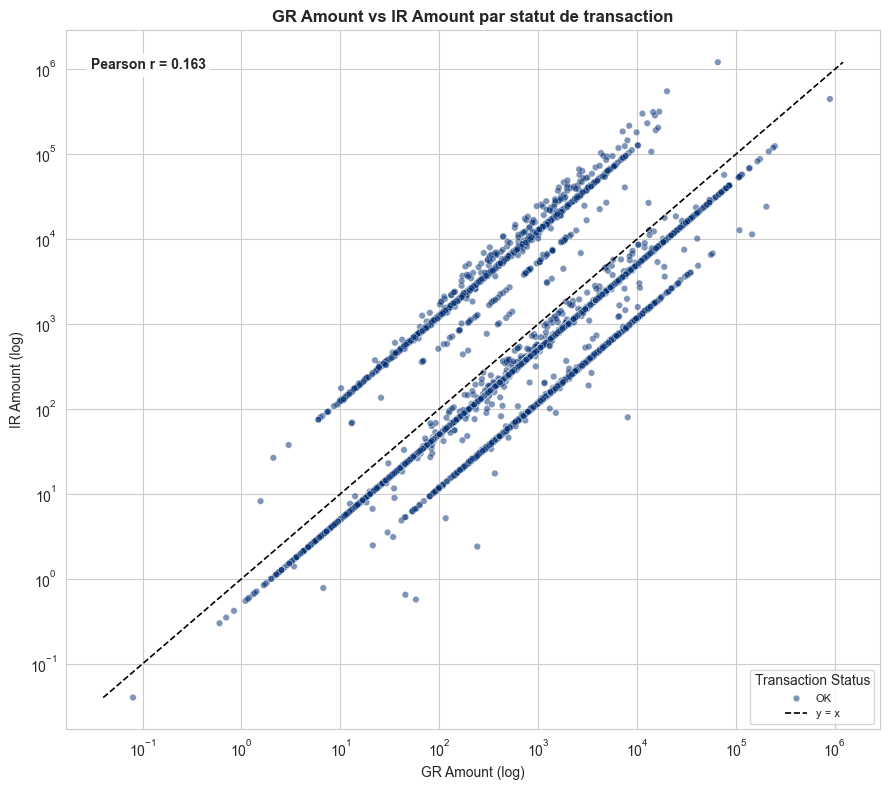


INTERPRETATION - GR Amount vs IR Amount
- r = 0.163 sur l'ensemble du jeu de donnees (294,722 lignes), soit une correlation negligeable.
- 4.3% des points de l'echantillon affiche ont un GR Amount ou IR Amount nul et ont ete exclus de la vue log-log (transactions ).
- Les points proches de la droite y=x correspondent aux transactions OK (GR ~ IR), tandis que les ecarts importants signalent des montants factures tres differents des montants receptionnes.


  [OK] Figure saved -> src\docs\figures\scatterplots\aging_vs_risk.png


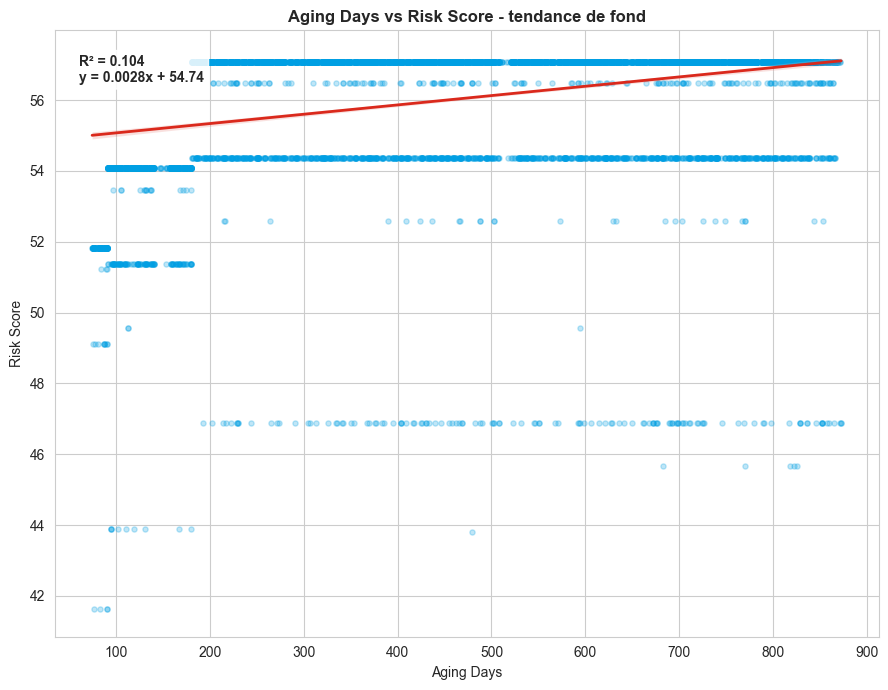


INTERPRETATION - Aging Days vs Risk Score
- La regression lineaire donne Risk Score = 0.0028 x Aging Days + 54.74, avec R² = 0.104.
- Le risque augmente avec l ancienn ete de la transaction, meme si l'anciennete seule n'explique qu'une part limitee de la variance du score (R² = 0.104).


  [OK] Figure saved -> src\docs\figures\scatterplots\quantity_vs_amount_per_qty.png


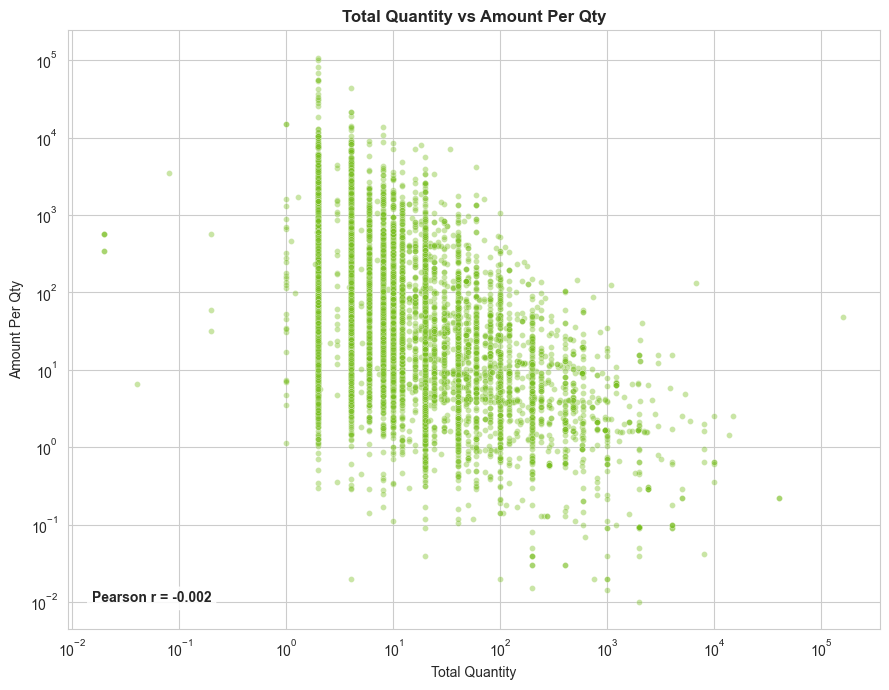


INTERPRETATION - Total Quantity vs Amount Per Qty
- r = -0.002 (correlation negligeable, signe negatif).
- Le lien est quasi inexistant : commander de plus grandes quantites ne se traduit pas ici par un cout unitaire mecaniquement plus faible. L'hypothese d'un effet de volume (remise quantite) n'est pas verifiee sur ce perimetre de donnees.


In [14]:
# Figure 1: GR Amount vs IR Amount, coloured by Transaction Status
sample_n = min(8000, len(eda_df))
sample_df = eda_df.sample(n=sample_n, random_state=42)

r_gr_ir, p_gr_ir = pearsonr(eda_df['GR Amount'], eda_df['IR Amount'])

fig, ax = plt.subplots(figsize=(9, 8))
plot_df = sample_df[(sample_df['GR Amount'] > 0) & (sample_df['IR Amount'] > 0)]
status_order = [s for s in ['OK', 'DELIVERED_NOT_INVOICED', 'INVOICED_NOT_DELIVERED', 'INCOMPLETE']
                 if s in plot_df['Transaction Status'].unique()]
sns.scatterplot(
    data=plot_df, x='GR Amount', y='IR Amount', hue='Transaction Status',
    hue_order=status_order, palette=FORVIA_COLORS[:len(status_order)],
    alpha=0.5, s=22, ax=ax,
)
lim_max = max(plot_df['GR Amount'].max(), plot_df['IR Amount'].max())
lim_min = min(plot_df['GR Amount'].min(), plot_df['IR Amount'].min())
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1.2, label='y = x')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("GR Amount vs IR Amount par statut de transaction", fontweight='bold')
ax.set_xlabel("GR Amount (log)")
ax.set_ylabel("IR Amount (log)")
ax.text(
    0.03, 0.96, f"Pearson r = {r_gr_ir:.3f}", transform=ax.transAxes, va='top', fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
)
ax.legend(title='Transaction Status', loc='lower right', fontsize=8)
plt.tight_layout()
savefig(fig, 'scatterplots', 'gr_vs_ir.png')
plt.show()

excluded_pct = (1 - len(plot_df) / len(sample_df)) * 100
print("\nINTERPRETATION - GR Amount vs IR Amount")
print("=" * 80)
print(
    f"- r = {r_gr_ir:.3f} sur l'ensemble du jeu de donnees ({len(eda_df):,} lignes), "
    f"soit une correlation {corr_strength(r_gr_ir)}."
)
print(
    f"- {excluded_pct:.1f}% des points de l'echantillon affiche ont un GR Amount ou IR Amount nul "
    f"et ont ete exclus de la vue log-log (transactions {'/'.join(s for s in status_order if s != 'OK')})."
)
print(
    "- Les points proches de la droite y=x correspondent aux transactions OK (GR ~ IR), "
    "tandis que les ecarts importants signalent des montants factures tres differents "
    "des montants receptionnes."
)

# Figure 2: Aging Days vs Risk Score with regression line and R^2
sample_df2 = eda_df.sample(n=sample_n, random_state=42)
slope, intercept = np.polyfit(eda_df['Aging Days'], eda_df['Risk Score'], 1)
r2 = eda_df['Aging Days'].corr(eda_df['Risk Score']) ** 2

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(
    data=sample_df2, x='Aging Days', y='Risk Score',
    scatter_kws={'alpha': 0.25, 's': 14, 'color': FORVIA_COLORS[1]},
    line_kws={'color': FORVIA_COLORS[4], 'linewidth': 2},
    ax=ax,
)
ax.set_title("Aging Days vs Risk Score - tendance de fond", fontweight='bold')
ax.text(
    0.03, 0.96, f"R² = {r2:.3f}\ny = {slope:.4f}x + {intercept:.2f}",
    transform=ax.transAxes, va='top', fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
)
plt.tight_layout()
savefig(fig, 'scatterplots', 'aging_vs_risk.png')
plt.show()

print("\nINTERPRETATION - Aging Days vs Risk Score")
print("=" * 80)
print(
    f"- La regression lineaire donne Risk Score = {slope:.4f} x Aging Days + {intercept:.2f}, "
    f"avec R² = {r2:.3f}."
)
print(
    f"- {'Le risque augmente avec l ancienn ete de la transaction' if slope > 0 else 'Le risque ne progresse pas avec l anciennete dans ce jeu de donnees'}, "
    f"meme si l'anciennete seule n'explique qu'une part {('limitee' if r2 < 0.3 else 'importante')} "
    f"de la variance du score (R² = {r2:.3f})."
)

# Figure 3: Total Quantity vs Amount Per Qty (expected negative relationship)
r_qty_pq = eda_df['Total Quantity'].corr(eda_df['Amount Per Qty'])
plot_df3 = sample_df2[(sample_df2['Total Quantity'] > 0) & (sample_df2['Amount Per Qty'] > 0)]

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=plot_df3, x='Total Quantity', y='Amount Per Qty',
    alpha=0.4, s=18, color=FORVIA_COLORS[2], ax=ax,
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Total Quantity vs Amount Per Qty", fontweight='bold')
ax.text(
    0.03, 0.04, f"Pearson r = {r_qty_pq:.3f}", transform=ax.transAxes, va='bottom', fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
)
plt.tight_layout()
savefig(fig, 'scatterplots', 'quantity_vs_amount_per_qty.png')
plt.show()

print("\nINTERPRETATION - Total Quantity vs Amount Per Qty")
print("=" * 80)
print(f"- r = {r_qty_pq:.3f} (correlation {corr_strength(r_qty_pq)}, signe {'negatif' if r_qty_pq < 0 else 'positif'}).")
if abs(r_qty_pq) < 0.05:
    print(
        "- Le lien est quasi inexistant : commander de plus grandes quantites ne se traduit pas "
        "ici par un cout unitaire mecaniquement plus faible. L'hypothese d'un effet de volume "
        "(remise quantite) n'est pas verifiee sur ce perimetre de donnees."
    )
else:
    print(
        "- La tendance negative attendue (plus la quantite est elevee, plus le cout unitaire "
        "diminue) est observable, meme si la dispersion reste importante."
    )

## Partie 3 - Boxplots et valeurs aberrantes (Rapport 3.3.3)

Boxplots (echelle logarithmique) pour `Amount`, `GR Amount`, `IR Amount` et
`Amount Per Qty`, avec calcul de la mediane, des quartiles (Q1/Q3), de
l'IQR, des bornes d'outliers et du nombre/pourcentage de valeurs aberrantes
selon la regle de Tukey (`Q1 - 1.5*IQR` / `Q3 + 1.5*IQR`).

Figure enregistree dans `src/docs/figures/outliers/boxplots_amounts.png`.


  [OK] Figure saved -> src\docs\figures\outliers\boxplots_amounts.png


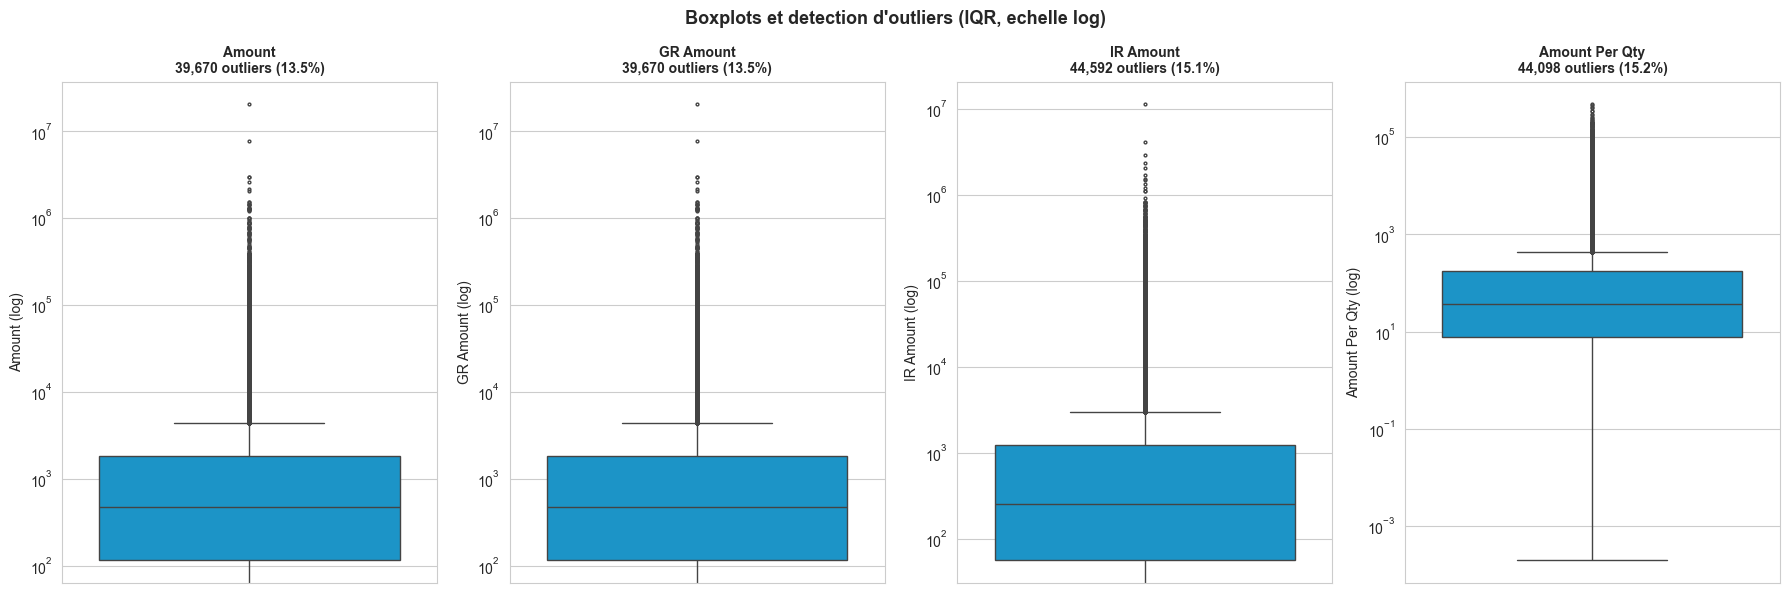


RESUME DES OUTLIERS (methode IQR = Q3 + 1.5*IQR / Q1 - 1.5*IQR)


,variable,median,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,Amount,466.11,115.08,"1,834.20","1,719.12","-2,463.59","4,412.87",39670,13.46%
1,GR Amount,466.11,115.08,"1,834.20","1,719.12","-2,463.59","4,412.87",39670,13.46%
2,IR Amount,255.39,56.16,"1,240.00","1,183.84","-1,719.60","3,015.76",44592,15.13%
3,Amount Per Qty,37.25,7.93,180.78,172.85,-251.35,440.06,44098,15.22%



INTERPRETATION - Outliers
- La variable la plus impactee par les valeurs extremes est 'Amount Per Qty' avec 44,098 outliers (15.2% des lignes), au-dela du seuil 440.06.
- Ces outliers correspondent generalement a des commandes de tres forte valeur (gros volumes, equipements specifiques) plutot qu'a des erreurs de saisie isolees, mais ils doivent etre controles avant toute modelisation (winsorisation ou transformation logarithmique).


In [15]:
# Boxplots with IQR-based outlier diagnostics for the key monetary variables
outlier_vars = [c for c in ['Amount', 'GR Amount', 'IR Amount', 'Amount Per Qty'] if c in eda_df.columns]
outlier_summary = []

fig, axes = plt.subplots(1, len(outlier_vars), figsize=(4.5 * len(outlier_vars), 6))
if len(outlier_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, outlier_vars):
    series = eda_df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((series < lower) | (series > upper)).sum())
    pct_outliers = n_outliers / len(series) * 100

    sns.boxplot(y=series, ax=ax, color=FORVIA_COLORS[1], fliersize=2)
    ax.set_yscale('log')
    ax.set_title(f"{col}\n{n_outliers:,} outliers ({pct_outliers:.1f}%)", fontweight='bold', fontsize=10)
    ax.set_ylabel(f"{col} (log)")

    outlier_summary.append({
        'variable': col, 'median': series.median(), 'q1': q1, 'q3': q3, 'iqr': iqr,
        'lower_bound': lower, 'upper_bound': upper, 'n_outliers': n_outliers, 'pct_outliers': pct_outliers,
    })

fig.suptitle("Boxplots et detection d'outliers (IQR, echelle log)", fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, 'outliers', 'boxplots_amounts.png')
plt.show()

outlier_summary_df = pd.DataFrame(outlier_summary)
print("\nRESUME DES OUTLIERS (methode IQR = Q3 + 1.5*IQR / Q1 - 1.5*IQR)")
print("=" * 80)
display(outlier_summary_df.style.format({
    'median': '{:,.2f}', 'q1': '{:,.2f}', 'q3': '{:,.2f}', 'iqr': '{:,.2f}',
    'lower_bound': '{:,.2f}', 'upper_bound': '{:,.2f}', 'pct_outliers': '{:.2f}%',
}))

print("\nINTERPRETATION - Outliers")
print("=" * 80)
top_outlier_var = outlier_summary_df.loc[outlier_summary_df['pct_outliers'].idxmax()]
print(
    f"- La variable la plus impactee par les valeurs extremes est '{top_outlier_var['variable']}' "
    f"avec {top_outlier_var['n_outliers']:,} outliers ({top_outlier_var['pct_outliers']:.1f}% des lignes), "
    f"au-dela du seuil {top_outlier_var['upper_bound']:,.2f}."
)
print(
    "- Ces outliers correspondent generalement a des commandes de tres forte valeur (gros volumes, "
    "equipements specifiques) plutot qu'a des erreurs de saisie isolees, mais ils doivent etre "
    "controles avant toute modelisation (winsorisation ou transformation logarithmique)."
)

## Partie 4 - Distribution des montants (Rapport 3.3.3)

Trois vues complementaires de la distribution de `Amount` :

1. histogramme sur l'echelle brute (avec KDE) ;
2. histogramme de `log(1 + Amount)` (avec KDE) ;
3. estimation de densite (KDE) seule, pour visualiser la forme de la queue de
   distribution.

L'objectif est de montrer que la distribution brute est fortement
**asymetrique a droite** (longue queue de quelques transactions de tres
grande valeur), et que la transformation logarithmique la rend beaucoup
plus proche d'une distribution symetrique.

Figure enregistree dans `src/docs/figures/distributions/amount_distribution.png`.


  [OK] Figure saved -> src\docs\figures\distributions\amount_distribution.png


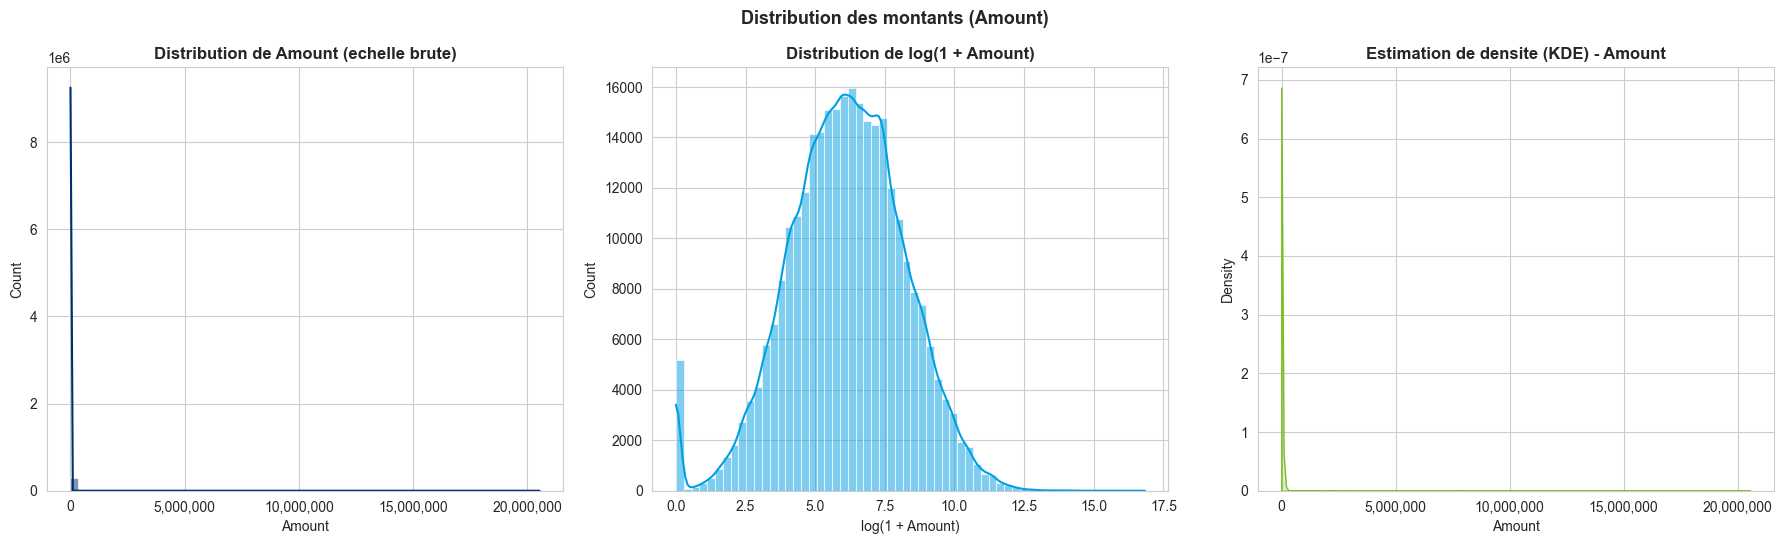


INTERPRETATION - Distribution de Amount
- Skewness (asymetrie) sur l'echelle brute : 337.39 -> distribution tres etalee a droite (quelques transactions de tres forte valeur dominent visuellement l'histogramme).
- Skewness apres transformation log(1+x) : -0.23 -> la transformation logarithmique rapproche fortement la distribution d'une forme symetrique, ce qui la rend plus adaptee a la modelisation statistique.
- 1.72% des transactions ont un Amount egal a 0 (transactions sans reception, categorie INCOMPLETE).
- 99% des transactions ont un Amount inferieur a 46,067.40, alors que la valeur maximale observee atteint 20,540,825.28 : la queue de distribution est longue et concentre un faible nombre de transactions de tres grande valeur.


In [16]:
# Distribution of Amount: raw histogram, log1p histogram, and KDE
amount = eda_df['Amount'].dropna()
log_amount = np.log1p(amount)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

sns.histplot(amount, bins=60, kde=True, color=FORVIA_COLORS[0], ax=axes[0])
axes[0].set_title("Distribution de Amount (echelle brute)", fontweight='bold')
axes[0].set_xlabel("Amount")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))

sns.histplot(log_amount, bins=60, kde=True, color=FORVIA_COLORS[1], ax=axes[1])
axes[1].set_title("Distribution de log(1 + Amount)", fontweight='bold')
axes[1].set_xlabel("log(1 + Amount)")

sns.kdeplot(amount, fill=True, color=FORVIA_COLORS[2], ax=axes[2])
axes[2].set_title("Estimation de densite (KDE) - Amount", fontweight='bold')
axes[2].set_xlabel("Amount")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))

fig.suptitle("Distribution des montants (Amount)", fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, 'distributions', 'amount_distribution.png')
plt.show()

# --- Auto-generated interpretation ---------------------------------------
skew_raw = amount.skew()
skew_log = log_amount.skew()
zero_pct = (amount == 0).mean() * 100
p99 = amount.quantile(0.99)

print("\nINTERPRETATION - Distribution de Amount")
print("=" * 80)
print(f"- Skewness (asymetrie) sur l'echelle brute : {skew_raw:.2f} -> distribution tres etalee a droite "
      f"(quelques transactions de tres forte valeur dominent visuellement l'histogramme).")
print(f"- Skewness apres transformation log(1+x) : {skew_log:.2f} -> la transformation logarithmique "
      f"rapproche fortement la distribution d'une forme symetrique, ce qui la rend plus adaptee a la "
      f"modelisation statistique.")
print(f"- {zero_pct:.2f}% des transactions ont un Amount egal a 0 (transactions sans reception, "
      f"categorie INCOMPLETE).")
print(f"- 99% des transactions ont un Amount inferieur a {p99:,.2f}, alors que la valeur maximale "
      f"observee atteint {amount.max():,.2f} : la queue de distribution est longue et concentre "
      f"un faible nombre de transactions de tres grande valeur.")

## Partie 5 - Valeurs manquantes (Rapport 3.3.3)

Deux vues sur la qualite/completude des donnees :

1. un **barplot des pourcentages de valeurs manquantes** par colonne sur le
   dataset brut `Documents1.csv` ;
2. un **barplot de completude GR / IR** au niveau (PO, Item), construit a
   partir des indicateurs `has_gr` / `has_ir` (absence de mouvement de
   reception ou de facturation), qui constituent l'equivalent metier des
   "GR Date / GR Amount" et "IR Date / IR Amount" manquants.

L'objectif est de montrer que ces absences ne sont pas du bruit, mais
correspondent directement aux anomalies metier (`INCOMPLETE`,
`DELIVERED_NOT_INVOICED`, `INVOICED_NOT_DELIVERED`).

Figures enregistrees dans `src/docs/figures/missing_values/`.


  [OK] Figure saved -> src\docs\figures\missing_values\missing_values_raw.png


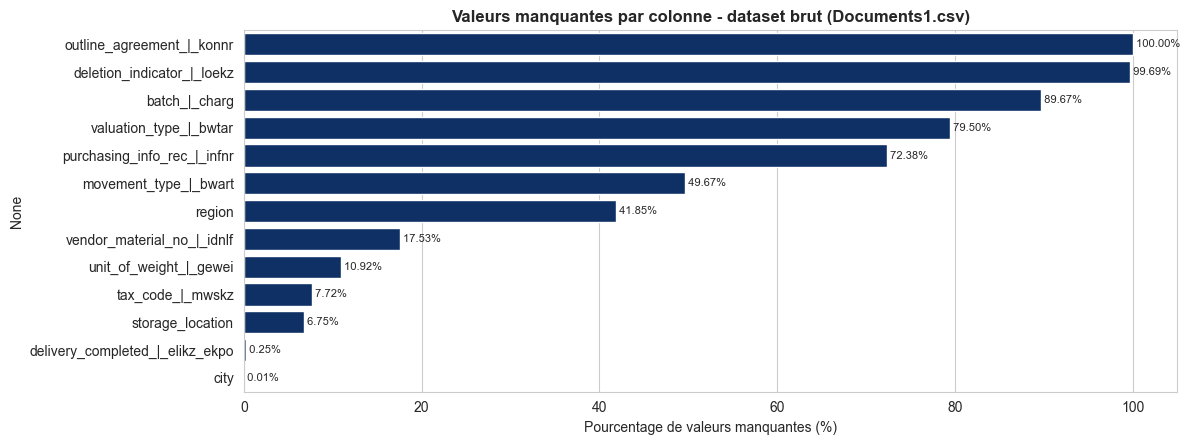

  [OK] Figure saved -> src\docs\figures\missing_values\gr_ir_completeness.png


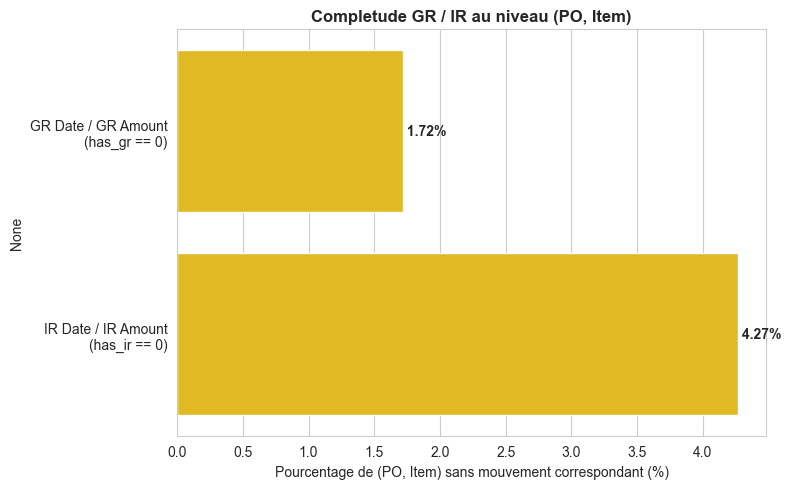


INTERPRETATION - Valeurs manquantes
- Colonne brute la plus impactee par les valeurs manquantes : 'outline_agreement_|_konnr' (616,800 valeurs, 100.00%).
- 1.72% des couples (PO, Item) n'ont aucun mouvement de reception (GR) associe, et 4.27% n'ont aucun mouvement de facturation (IR).
- Ces 'absences' ne sont pas des erreurs techniques mais correspondent directement aux anomalies metier recherchees (INCOMPLETE, DELIVERED_NOT_INVOICED, INVOICED_NOT_DELIVERED) : l'analyse des valeurs manquantes est donc un signal direct de detection d'anomalies P2P.


In [17]:
# 5a) Overall missing-value picture on the raw transaction-level dataset (df)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * max(len(missing_counts), 1))))
if len(missing_counts) > 0:
    missing_pct_raw = (missing_counts / len(df) * 100)
    sns.barplot(x=missing_pct_raw.values, y=missing_pct_raw.index, color=FORVIA_COLORS[0], ax=ax)
    ax.set_xlabel("Pourcentage de valeurs manquantes (%)")
    ax.set_title("Valeurs manquantes par colonne - dataset brut (Documents1.csv)", fontweight='bold')
    for i, v in enumerate(missing_pct_raw.values):
        ax.text(v, i, f" {v:.2f}%", va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, "Aucune valeur manquante dans le dataset brut", ha='center', va='center', fontsize=12)
    ax.set_axis_off()
plt.tight_layout()
savefig(fig, 'missing_values', 'missing_values_raw.png')
plt.show()

# 5b) Business-level missingness proxy: GR / IR completeness at (PO, Item) level
# A missing "GR Date" / "GR Amount" corresponds to has_gr == 0 (no goods-receipt
# movement for the PO+Item); similarly for IR.
gr_ir_missing = pd.Series({
    'GR Date / GR Amount\n(has_gr == 0)': (feat_df['has_gr'] == 0).mean() * 100,
    'IR Date / IR Amount\n(has_ir == 0)': (feat_df['has_ir'] == 0).mean() * 100,
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=gr_ir_missing.values, y=gr_ir_missing.index, color=FORVIA_COLORS[3], ax=ax)
ax.set_xlabel("Pourcentage de (PO, Item) sans mouvement correspondant (%)")
ax.set_title("Completude GR / IR au niveau (PO, Item)", fontweight='bold')
for i, v in enumerate(gr_ir_missing.values):
    ax.text(v, i, f" {v:.2f}%", va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
savefig(fig, 'missing_values', 'gr_ir_completeness.png')
plt.show()

print("\nINTERPRETATION - Valeurs manquantes")
print("=" * 80)
if len(missing_counts) > 0:
    top_missing = missing_counts.index[0]
    print(f"- Colonne brute la plus impactee par les valeurs manquantes : '{top_missing}' "
          f"({missing_counts.iloc[0]:,} valeurs, {missing_counts.iloc[0] / len(df) * 100:.2f}%).")
else:
    print("- Le dataset brut (Documents1.csv) ne contient aucune valeur manquante au sens strict (NaN) :"
          " l'absence de GR ou d'IR se traduit par l'absence d'une ligne de mouvement plutot que par un NaN.")
print(f"- {gr_ir_missing.iloc[0]:.2f}% des couples (PO, Item) n'ont aucun mouvement de reception (GR) "
      f"associe, et {gr_ir_missing.iloc[1]:.2f}% n'ont aucun mouvement de facturation (IR).")
print("- Ces 'absences' ne sont pas des erreurs techniques mais correspondent directement aux "
      "anomalies metier recherchees (INCOMPLETE, DELIVERED_NOT_INVOICED, INVOICED_NOT_DELIVERED) : "
      "l'analyse des valeurs manquantes est donc un signal direct de detection d'anomalies P2P.")

## Partie 6 - Repartition des classes (Rapport 3.3.3)

Pie chart et bar chart de la variable `Transaction Status`
(`OK`, `DELIVERED_NOT_INVOICED`, `INVOICED_NOT_DELIVERED`, `INCOMPLETE`),
avec effectifs, pourcentages et calcul de l'**imbalance ratio**
(classe majoritaire / classe minoritaire).

Figure enregistree dans
`src/docs/figures/class_distribution/transaction_status_distribution.png`.


C:\Users\1boughai\AppData\Local\Temp\ipykernel_17648\3256427201.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette=colors, ax=axes[1])


  [OK] Figure saved -> src\docs\figures\class_distribution\transaction_status_distribution.png


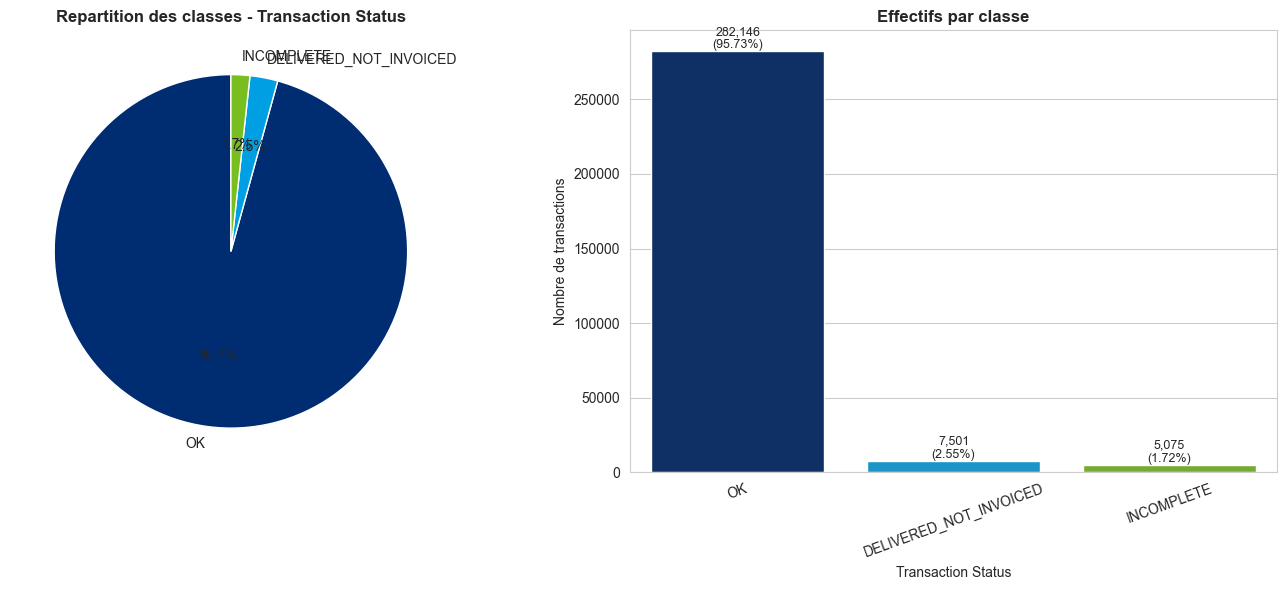


INTERPRETATION - Repartition des classes
  - OK                       :  282,146 (95.73%)
  - DELIVERED_NOT_INVOICED   :    7,501 ( 2.55%)
  - INCOMPLETE               :    5,075 ( 1.72%)

- Imbalance ratio (classe majoritaire / classe minoritaire) = OK / INCOMPLETE = 55.6.
- La classe 'OK' domine tres largement le jeu de donnees (95.73%), ce qui correspond a un fort desequilibre de classes typique des problemes de detection d'anomalies : un modele de classification devra utiliser des techniques de reequilibrage (SMOTE, ponderation des classes) pour ne pas ignorer les classes minoritaires.

- Note: la/les classe(s) ['INVOICED_NOT_DELIVERED'] mentionnee(s) dans le rapport n'apparaissent pas (ou avec un effectif nul) sur cet extrait de donnees.


In [18]:
status_counts = eda_df['Transaction Status'].value_counts()
status_pct = (status_counts / status_counts.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = FORVIA_COLORS[:len(status_counts)]
axes[0].pie(
    status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'},
)
axes[0].set_title("Repartition des classes - Transaction Status", fontweight='bold')

sns.barplot(x=status_counts.index, y=status_counts.values, palette=colors, ax=axes[1])
axes[1].set_title("Effectifs par classe", fontweight='bold')
axes[1].set_xlabel("Transaction Status")
axes[1].set_ylabel("Nombre de transactions")
for i, (count, pct) in enumerate(zip(status_counts.values, status_pct.values)):
    axes[1].text(i, count, f"{count:,}\n({pct:.2f}%)", ha='center', va='bottom', fontsize=9)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
savefig(fig, 'class_distribution', 'transaction_status_distribution.png')
plt.show()

imbalance_ratio = status_counts.max() / status_counts.min()
majority_class = status_counts.idxmax()
minority_class = status_counts.idxmin()

print("\nINTERPRETATION - Repartition des classes")
print("=" * 80)
for status, count, pct in zip(status_counts.index, status_counts.values, status_pct.values):
    print(f"  - {status:25s}: {count:8,} ({pct:5.2f}%)")
print(f"\n- Imbalance ratio (classe majoritaire / classe minoritaire) = "
      f"{majority_class} / {minority_class} = {imbalance_ratio:,.1f}.")
print(f"- La classe '{majority_class}' domine tres largement le jeu de donnees ({status_pct.max():.2f}%), "
      f"ce qui correspond a un fort desequilibre de classes typique des problemes de detection "
      f"d'anomalies : un modele de classification devra utiliser des techniques de reequilibrage "
      f"(SMOTE, ponderation des classes) pour ne pas ignorer les classes minoritaires.")

expected_classes = {'OK', 'INVOICED_NOT_DELIVERED', 'DELIVERED_NOT_INVOICED'}
absent_classes = expected_classes - set(status_counts.index)
if absent_classes:
    print(f"\n- Note: la/les classe(s) {sorted(absent_classes)} mentionnee(s) dans le rapport "
          f"n'apparaissent pas (ou avec un effectif nul) sur cet extrait de donnees.")

## Partie 7 - Analyse des doublons / mouvements par poste (Rapport 3.3.3)

Analyse, au niveau du dataset brut (`Documents1.csv`), du nombre de
**mouvements (lignes GR/IR)** par couple `(purchasing_document_|_ebeln,
item_|_ebelp)` :

- nombre total de lignes ;
- nombre de couples (PO, Item) distincts ;
- nombre moyen / median / maximum de mouvements par poste ;
- histogramme de la distribution du nombre de mouvements.

Cette analyse met en evidence la structure "doublons attendus" du dataset
SAP P2P : chaque poste peut comporter plusieurs lignes (GR, IR, retours,
mouvements partiels) qui ne sont pas des doublons au sens data-quality mais
des evenements metier distincts.

Figure enregistree dans
`src/docs/figures/duplicates/movements_per_item_distribution.png`.


  [OK] Figure saved -> src\docs\figures\duplicates\movements_per_item_distribution.png


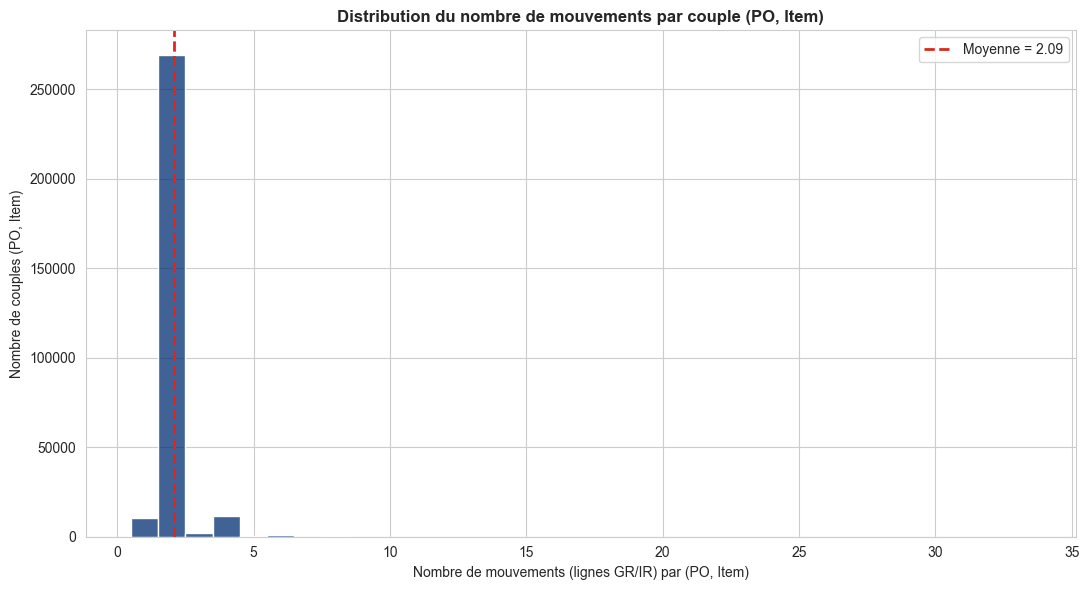


INTERPRETATION - Analyse des doublons / mouvements
- Nombre total de lignes (mouvements GR/IR) : 616,800
- Nombre de couples (PO, Item) distincts : 295,651
- Nombre moyen de mouvements par couple (PO, Item) : 2.09 (mediane = 2, maximum = 33)

- 91.1% des couples (PO, Item) ont exactement 2 mouvements (typiquement 1 GR + 1 IR, soit le cas 'OK').
- 3.5% n'ont qu'un seul mouvement (GR seul ou IR seul -> transaction incomplete).
- 5.4% ont plus de 2 mouvements (retours, livraisons/facturations partielles multiples), avec un maximum observe de 33 mouvements pour un meme poste.


In [19]:
# Movements per (PO, Item) on the raw transaction-level dataset
movements_per_item = df.groupby(['purchasing_document_|_ebeln', 'item_|_ebelp']).size()

n_total_rows = len(df)
n_po_item_pairs = movements_per_item.shape[0]
mean_movements = movements_per_item.mean()
median_movements = movements_per_item.median()
max_movements = movements_per_item.max()

fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(movements_per_item, bins=range(1, int(max_movements) + 2), discrete=True,
              color=FORVIA_COLORS[0], ax=ax)
ax.set_title("Distribution du nombre de mouvements par couple (PO, Item)", fontweight='bold')
ax.set_xlabel("Nombre de mouvements (lignes GR/IR) par (PO, Item)")
ax.set_ylabel("Nombre de couples (PO, Item)")
ax.axvline(mean_movements, color=FORVIA_COLORS[4], linestyle='--', linewidth=2,
            label=f"Moyenne = {mean_movements:.2f}")
ax.legend()
plt.tight_layout()
savefig(fig, 'duplicates', 'movements_per_item_distribution.png')
plt.show()

print("\nINTERPRETATION - Analyse des doublons / mouvements")
print("=" * 80)
print(f"- Nombre total de lignes (mouvements GR/IR) : {n_total_rows:,}")
print(f"- Nombre de couples (PO, Item) distincts : {n_po_item_pairs:,}")
print(f"- Nombre moyen de mouvements par couple (PO, Item) : {mean_movements:.2f} "
      f"(mediane = {median_movements:.0f}, maximum = {max_movements:.0f})")

top_counts = movements_per_item.value_counts().sort_index()
two_pct = top_counts.get(2, 0) / n_po_item_pairs * 100
one_pct = top_counts.get(1, 0) / n_po_item_pairs * 100
more_pct = 100 - two_pct - one_pct

print(f"\n- {two_pct:.1f}% des couples (PO, Item) ont exactement 2 mouvements "
      f"(typiquement 1 GR + 1 IR, soit le cas 'OK').")
print(f"- {one_pct:.1f}% n'ont qu'un seul mouvement (GR seul ou IR seul -> transaction incomplete).")
print(f"- {more_pct:.1f}% ont plus de 2 mouvements (retours, livraisons/facturations partielles "
      f"multiples), avec un maximum observe de {max_movements:.0f} mouvements pour un meme poste.")

## Partie 8 - Analyse des formats de dates (Rapport 3.3.3)

Histogrammes de la distribution temporelle pour :

- la **date de creation** (`document_date_|_bedat`) ;
- la **GR Date** (dates de mouvement de reception, lignes
  `po_history_category_|_bewtp == 'E'`) ;
- l'**IR Date** (dates de mouvement de facturation, lignes
  `po_history_category_|_bewtp == 'Q'`).

Pour chaque variable, le nombre de **formats de date detectes** (parmi
`YYYY-MM-DD`, `DD.MM.YYYY`, `DD/MM/YYYY`, `YYYYMMDD`) et le **taux de dates
invalides avant normalisation** sont calcules et affiches.

Figure enregistree dans `src/docs/figures/dates/date_distributions.png`.


  [OK] Figure saved -> src\docs\figures\dates\date_distributions.png


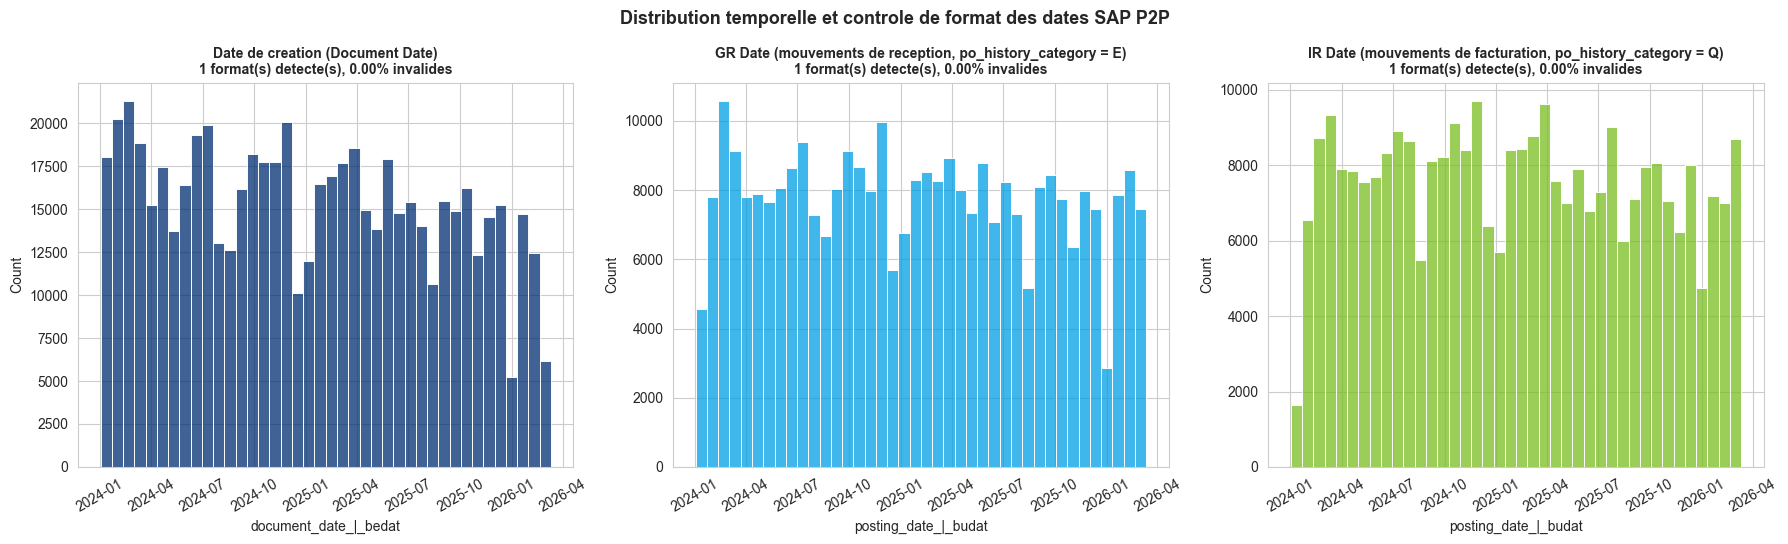


INTERPRETATION - Formats de dates
- Date de creation (Document Date) (document_date_|_bedat, n=616,800) :
    Format(s) detecte(s) : {'YYYY-MM-DD': 616800}
    Taux de dates invalides avant normalisation : 0.00%
- GR Date (mouvements de reception, po_history_category = E) (posting_date_|_budat, n=310,408) :
    Format(s) detecte(s) : {'YYYY-MM-DD': 310408}
    Taux de dates invalides avant normalisation : 0.00%
- IR Date (mouvements de facturation, po_history_category = Q) (posting_date_|_budat, n=303,027) :
    Format(s) detecte(s) : {'YYYY-MM-DD': 303027}
    Taux de dates invalides avant normalisation : 0.00%

- Sur cet extrait, les colonnes de dates sont deja normalisees au format ISO (YYYY-MM-DD) avec 0% de valeurs invalides : la chaine de preparation amont (Data Preparation) a deja resolu les heterogeneites de formats SAP (DD.MM.YYYY, YYYYMMDD, etc.) typiquement rencontrees sur des exports bruts.


In [20]:
import re

DATE_FORMAT_PATTERNS = {
    'YYYY-MM-DD': re.compile(r'^\d{4}-\d{2}-\d{2}$'),
    'DD.MM.YYYY': re.compile(r'^\d{2}\.\d{2}\.\d{4}$'),
    'DD/MM/YYYY': re.compile(r'^\d{2}/\d{2}/\d{4}$'),
    'YYYYMMDD':   re.compile(r'^\d{8}$'),
}

def detect_date_formats(series):
    """Detect raw string date formats and the invalid (unparseable) rate."""
    raw = series.dropna().astype(str)
    format_counts = {}
    for name, pattern in DATE_FORMAT_PATTERNS.items():
        format_counts[name] = int(raw.str.match(pattern).sum())
    classified = sum(format_counts.values())
    format_counts['AUTRE / NON RECONNU'] = int(len(raw) - classified)

    parsed = pd.to_datetime(series, errors='coerce', format='mixed')
    invalid_rate = (parsed.isna().sum() - series.isna().sum()) / max(len(series), 1) * 100

    return format_counts, invalid_rate, parsed

date_specs = [
    ('document_date_|_bedat', None, "Date de creation (Document Date)"),
    ('posting_date_|_budat', 'E', "GR Date (mouvements de reception, po_history_category = E)"),
    ('posting_date_|_budat', 'Q', "IR Date (mouvements de facturation, po_history_category = Q)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
date_report = []

for ax, (col, category_filter, label) in zip(axes, date_specs):
    if col not in df.columns:
        ax.set_axis_off()
        continue

    series = df[col] if category_filter is None else df.loc[df['po_history_category_|_bewtp'] == category_filter, col]
    formats, invalid_rate, parsed = detect_date_formats(series)
    n_formats = sum(1 for v in formats.values() if v > 0)

    sns.histplot(parsed.dropna(), bins=40, color=FORVIA_COLORS[axes.tolist().index(ax) % len(FORVIA_COLORS)], ax=ax)
    ax.set_title(f"{label}\n{n_formats} format(s) detecte(s), {invalid_rate:.2f}% invalides", fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=30)

    date_report.append({'variable': label, 'column': col, 'n_formats': n_formats,
                         'formats': {k: v for k, v in formats.items() if v > 0},
                         'invalid_rate_pct': invalid_rate, 'n_values': len(series.dropna())})

fig.suptitle("Distribution temporelle et controle de format des dates SAP P2P", fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, 'dates', 'date_distributions.png')
plt.show()

print("\nINTERPRETATION - Formats de dates")
print("=" * 80)
for rep in date_report:
    print(f"- {rep['variable']} ({rep['column']}, n={rep['n_values']:,}) :")
    print(f"    Format(s) detecte(s) : {rep['formats']}")
    print(f"    Taux de dates invalides avant normalisation : {rep['invalid_rate_pct']:.2f}%")

all_single_format = all(r['n_formats'] <= 1 for r in date_report)
all_valid = all(r['invalid_rate_pct'] == 0 for r in date_report)
if all_single_format and all_valid:
    print("\n- Sur cet extrait, les colonnes de dates sont deja normalisees au format ISO "
          "(YYYY-MM-DD) avec 0% de valeurs invalides : la chaine de preparation amont "
          "(Data Preparation) a deja resolu les heterogeneites de formats SAP "
          "(DD.MM.YYYY, YYYYMMDD, etc.) typiquement rencontrees sur des exports bruts.")
else:
    print("\n- Des formats de dates heterogenes et/ou des valeurs invalides ont ete detectes : "
          "une normalisation explicite des dates est necessaire avant toute analyse temporelle.")

## Partie 9 - Benchmark des correlations (Rapport 3.3.2)

Tableau recapitulatif des relations bivariees les plus importantes pour le
rapport (`GR Amount` vs `IR Amount`, `Aging Days` vs `Risk Score`,
`Total Quantity` vs `Amount Per Qty`, et les variantes `Delivery Gap` /
`Invoice Gap`), avec le coefficient de correlation reel observe et une
interpretation automatique (conforme ou non a l'hypothese de depart).

Exports :
- `src/docs/figures/benchmarks/correlation_benchmark.csv`
- `src/docs/figures/benchmarks/correlation_benchmark.png`


,Relation,Correlation,Interpretation
0,GR Amount vs IR Amount,0.163,"Negligeable, positive (conforme a l'attendu: f..."
1,Aging Days vs Risk Score,0.322,"Faible, positive (conforme a l'attendu: correl..."
2,Total Quantity vs Amount Per Qty,-0.002,Quasi nulle (r=-0.002) - relation correlation ...
3,Delivery Gap vs Invoice Gap,0.118,"Negligeable, positive (conforme a l'attendu: l..."
4,Invoice Gap vs Risk Score,-0.384,"Faible, negative (sens inverse de l'attendu: u..."


  [OK] Tableau exporte -> src\docs\figures\benchmarks\correlation_benchmark.csv


  [OK] Figure saved -> src\docs\figures\benchmarks\correlation_benchmark.png


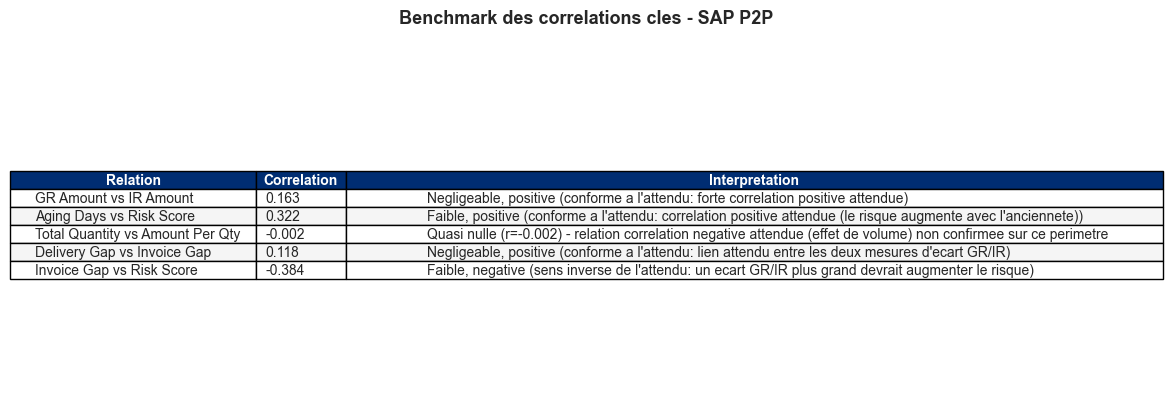


INTERPRETATION - Benchmark des correlations
- GR Amount vs IR Amount             : r = +0.163 -> Negligeable, positive (conforme a l'attendu: forte correlation positive attendue)
- Aging Days vs Risk Score           : r = +0.322 -> Faible, positive (conforme a l'attendu: correlation positive attendue (le risque augmente avec l'anciennete))
- Total Quantity vs Amount Per Qty   : r = -0.002 -> Quasi nulle (r=-0.002) - relation correlation negative attendue (effet de volume) non confirmee sur ce perimetre
- Delivery Gap vs Invoice Gap        : r = +0.118 -> Negligeable, positive (conforme a l'attendu: lien attendu entre les deux mesures d'ecart GR/IR)
- Invoice Gap vs Risk Score          : r = -0.384 -> Faible, negative (sens inverse de l'attendu: un ecart GR/IR plus grand devrait augmenter le risque)


In [21]:
def interpret_relation(r, expected_sign, expected_label):
    strength = corr_strength(r)
    sign_ok = (r >= 0) == (expected_sign >= 0)
    if abs(r) < 0.05:
        return f"Quasi nulle (r={r:.3f}) - relation {expected_label} non confirmee sur ce perimetre"
    if sign_ok:
        return f"{strength.capitalize()}, {('positive' if r > 0 else 'negative')} (conforme a l'attendu: {expected_label})"
    return f"{strength.capitalize()}, {('positive' if r > 0 else 'negative')} (sens inverse de l'attendu: {expected_label})"

benchmark_rows = []

if {'GR Amount', 'IR Amount'} <= set(eda_df.columns):
    r = eda_df['GR Amount'].corr(eda_df['IR Amount'])
    benchmark_rows.append({
        'Relation': 'GR Amount vs IR Amount',
        'Correlation': round(r, 3),
        'Interpretation': interpret_relation(r, +1, 'forte correlation positive attendue'),
    })

if {'Aging Days', 'Risk Score'} <= set(eda_df.columns):
    r = eda_df['Aging Days'].corr(eda_df['Risk Score'])
    benchmark_rows.append({
        'Relation': 'Aging Days vs Risk Score',
        'Correlation': round(r, 3),
        'Interpretation': interpret_relation(r, +1, 'correlation positive attendue (le risque augmente avec l\'anciennete)'),
    })

if {'Total Quantity', 'Amount Per Qty'} <= set(eda_df.columns):
    r = eda_df['Total Quantity'].corr(eda_df['Amount Per Qty'])
    benchmark_rows.append({
        'Relation': 'Total Quantity vs Amount Per Qty',
        'Correlation': round(r, 3),
        'Interpretation': interpret_relation(r, -1, 'correlation negative attendue (effet de volume)'),
    })

if {'Delivery Gap', 'Invoice Gap'} <= set(eda_df.columns):
    r = eda_df['Delivery Gap'].corr(eda_df['Invoice Gap'])
    benchmark_rows.append({
        'Relation': 'Delivery Gap vs Invoice Gap',
        'Correlation': round(r, 3),
        'Interpretation': interpret_relation(r, +1, 'lien attendu entre les deux mesures d\'ecart GR/IR'),
    })

if {'Invoice Gap', 'Risk Score'} <= set(eda_df.columns):
    r = eda_df['Invoice Gap'].corr(eda_df['Risk Score'])
    benchmark_rows.append({
        'Relation': 'Invoice Gap vs Risk Score',
        'Correlation': round(r, 3),
        'Interpretation': interpret_relation(r, +1, 'un ecart GR/IR plus grand devrait augmenter le risque'),
    })

benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df)

# Export CSV
csv_path = FIG_DIRS['benchmarks'] / 'correlation_benchmark.csv'
benchmark_df.to_csv(csv_path, index=False)
print(f"  [OK] Tableau exporte -> {csv_path.relative_to(project_root)}")

# Export PNG table
fig, ax = plt.subplots(figsize=(13, 0.6 * len(benchmark_df) + 1.2))
ax.axis('off')
table = ax.table(
    cellText=benchmark_df.values,
    colLabels=benchmark_df.columns,
    cellLoc='left',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(benchmark_df.columns))))
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(FORVIA_COLORS[0])
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F5F5F5' if row % 2 == 0 else 'white')
ax.set_title("Benchmark des correlations cles - SAP P2P", fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
savefig(fig, 'benchmarks', 'correlation_benchmark.png')
plt.show()

print("\nINTERPRETATION - Benchmark des correlations")
print("=" * 80)
for _, row in benchmark_df.iterrows():
    print(f"- {row['Relation']:35s}: r = {row['Correlation']:+.3f} -> {row['Interpretation']}")

## Recapitulatif - Section 11 (Rapport 3.3.2 & 3.3.3)

Cellule de verification finale : confirme que toutes les figures attendues
ont ete enregistrees dans `src/docs/figures/<sous-dossier>/`, rappelle le
mapping entre les noms de variables du rapport et les colonnes reellement
utilisees du dataset, et indique les datasets source.


In [22]:
# Final verification: confirm all expected figures were saved to disk
expected_figures = {
    'correlation/correlation_matrix.png': "Partie 1 - Matrice de correlation",
    'scatterplots/gr_vs_ir.png': "Partie 2 - GR Amount vs IR Amount",
    'scatterplots/aging_vs_risk.png': "Partie 2 - Aging Days vs Risk Score",
    'scatterplots/quantity_vs_amount_per_qty.png': "Partie 2 - Total Quantity vs Amount Per Qty",
    'outliers/boxplots_amounts.png': "Partie 3 - Boxplots / outliers",
    'distributions/amount_distribution.png': "Partie 4 - Distribution de Amount",
    'missing_values/missing_values_raw.png': "Partie 5 - Valeurs manquantes (dataset brut)",
    'missing_values/gr_ir_completeness.png': "Partie 5 - Completude GR/IR",
    'class_distribution/transaction_status_distribution.png': "Partie 6 - Repartition des classes",
    'duplicates/movements_per_item_distribution.png': "Partie 7 - Mouvements par poste",
    'dates/date_distributions.png': "Partie 8 - Formats de dates",
    'benchmarks/correlation_benchmark.png': "Partie 9 - Benchmark des correlations (PNG)",
    'benchmarks/correlation_benchmark.csv': "Partie 9 - Benchmark des correlations (CSV)",
}

print("RECAPITULATIF - SECTION 11 (Rapport 3.3.2 / 3.3.3)")
print("=" * 80)
print("\n1) Figures generees :")
all_ok = True
for rel_path, description in expected_figures.items():
    full_path = FIGURES_ROOT / rel_path
    exists = full_path.exists()
    all_ok &= exists
    status = "OK" if exists else "MANQUANT"
    print(f"  [{status:8s}] src/docs/figures/{rel_path:55s} ({description})")

print("\n2) Mapping des colonnes du rapport vers le dataset :")
for label, (col, desc) in COLUMN_MAP.items():
    status = "OK" if label in resolved_map else "MISSING (ignore)"
    print(f"  [{status:18s}] {label:20s} <- {col}")

print("\n3) Dataset utilise pour l'analyse :")
print(f"  - {FEATURES_FILE.relative_to(project_root)} ({feat_df.shape[0]:,} lignes, {feat_df.shape[1]} colonnes)")
print(f"  - {RISK_FILE.relative_to(project_root)} (Risk Score, {feat_df.shape[0]:,} lignes alignees)")

print("\n4) Statut global :")
if all_ok:
    print("  Toutes les figures attendues ont ete generees avec succes dans src/docs/figures/.")
else:
    print("  ATTENTION: certaines figures sont manquantes, voir le detail ci-dessus.")

RECAPITULATIF - SECTION 11 (Rapport 3.3.2 / 3.3.3)

1) Figures generees :
  [OK      ] src/docs/figures/correlation/correlation_matrix.png                      (Partie 1 - Matrice de correlation)
  [OK      ] src/docs/figures/scatterplots/gr_vs_ir.png                               (Partie 2 - GR Amount vs IR Amount)
  [OK      ] src/docs/figures/scatterplots/aging_vs_risk.png                          (Partie 2 - Aging Days vs Risk Score)
  [OK      ] src/docs/figures/scatterplots/quantity_vs_amount_per_qty.png             (Partie 2 - Total Quantity vs Amount Per Qty)
  [OK      ] src/docs/figures/outliers/boxplots_amounts.png                           (Partie 3 - Boxplots / outliers)
  [OK      ] src/docs/figures/distributions/amount_distribution.png                   (Partie 4 - Distribution de Amount)
  [OK      ] src/docs/figures/missing_values/missing_values_raw.png                   (Partie 5 - Valeurs manquantes (dataset brut))
  [OK      ] src/docs/figures/missing_values/gr_ir_c

## ✅ KEY INSIGHTS & NEXT STEPS

**Key Findings:**
- Dataset structure remains intact and ready for downstream processing.
- Advanced statistical profiling highlights strong asymmetry and outliers on monetary and quantity fields.
- GR / IR timing analysis shows a typical delay pattern, with a non-negligible share of long delays and negative delays to investigate.
- Supplier exploration reveals spend concentration and a first risk-oriented supplier view for future feature engineering.
- The notebook now contains robust handling for missing columns and business-oriented interpretations under each figure.

**Business Impact:**
- Better visibility on SAP P2P process quality.
- Clear identification of suspicious transaction patterns and operational exceptions.
- Stronger basis for anomaly detection and supplier risk analysis.

**Data Science Next Steps:**
- Proceed to Data Preparation with the cleaned and validated signals from this notebook.
- Engineer supplier-level and temporal features from the explored signals.
- Reserve final clustering, anomaly modeling, and ML training for the dedicated Modeling stage.

**Scope Reminder:**
- This notebook stays in the Data Understanding phase.
- It does not replace Data Preparation, Feature Engineering, or Modeling.

In [23]:
# 1. Charger les données
df = spark.read.csv("../../data/Contracts.csv", header=True, inferSchema=True)

# 2. Transformer les données
df_transformed = df.withColumn(
    "po_item_key",
    F.concat_ws("_",
        F.col("purchasing_document_|_ebeln"),
        F.col("item_|_ebelp")
    )
)

# 3. Ajouter colonnes
df_transformed = df_transformed.withColumn(
    "doc_number",
    F.split(F.col("po_item_key"), "_")[0]
).withColumn(
    "item_number",
    F.split(F.col("po_item_key"), "_")[1]
)

# 4. Afficher
df_transformed.show(5)

NameError: name 'spark' is not defined